<a href="https://colab.research.google.com/github/gabrielharom/AML-Final-Haro-Gabriel/blob/main/notebooks/final_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🎓 Capstone Project - Advanced Machine Learning
## TEC-VIII Programa de Especialización en Big Data Analytics aplicada a los Negocios

---

### 📋 Información del Proyecto

| Campo | Información |
|-------|-------------|
| **Nombre del Estudiante** | Claudia Crespo |
||Gabriel Haro|
||Angel Malpartida|
||Andrea Salas|
||Yaroli Santivañez|
| **Título del Proyecto** | Clasificación Multietiqueta de Patologías Torácicas con DenseNet121 y ResNet50 |
| **Fecha de Entrega** | 25/08/2026 |
| **Profesor** | Carlos Merino |

---

## 📑 Índice

1. [Resumen Ejecutivo](#1-resumen-ejecutivo)
2. [Configuración del Entorno](#2-configuración-del-entorno)
3. [Definición del Problema de Negocio](#3-definición-del-problema-de-negocio)
4. [Carga y Exploración de Datos](#4-carga-y-exploración-de-datos)
5. [Preprocesamiento de Datos](#5-preprocesamiento-de-datos)
6. [Diseño y Arquitectura del Modelo](#6-diseño-y-arquitectura-del-modelo)
7. [Entrenamiento del Modelo](#7-entrenamiento-del-modelo)
8. [Evaluación y Métricas](#8-evaluación-y-métricas)
9. [Interpretación de Resultados](#9-interpretación-de-resultados)
10. [Conclusiones y Recomendaciones de Negocio](#10-conclusiones-y-recomendaciones-de-negocio)
11. [Referencias](#11-referencias)

---
## 1. Resumen Ejecutivo

**Instrucciones:** Proporcione un resumen conciso (máximo 300 palabras) que incluya:
- Problema de negocio abordado
- Metodología utilizada
- Principales hallazgos
- Impacto esperado en el negocio

---
### Problema de negocio abordado

El retraso en el triaje de radiografías de tórax en entornos hospitalarios de alta demanda incrementa los tiempos de diagnóstico crítico. Este proyecto desarrolla un sistema de soporte automatizado basado en visión por computadora para la clasificación multietiqueta de 14 patologías pulmonares simultáneas sobre el dataset NIH Chest X-ray (34,999 radiografías disponibles), con el objetivo de priorizar la cola de lectura médica sin sustituir el juicio del radiólogo.  

### Metodología utilizada

Se implementó una partición estratificada a nivel de paciente (Train: 24,311; Validation: 5,245; Test: 5,443 imágenes) para evitar fuga de información. Se evaluaron y compararon dos arquitecturas de Deep Learning: DenseNet-121 y ResNet-50, ambas entrenadas en dos fases (Feature Extraction con congelamiento de capas y Fine-Tuning discriminativo con tasa de aprendizaje baja), optimizadas mediante Binary Cross-Entropy y evaluadas a través del ROC-AUC Macro y mapas de explicabilidad Grad-CAM.

### Principales hallazgos

En la evaluación final sobre el conjunto de Test, ResNet-50 alcanzó un ROC-AUC macro promedio de 0.7546, superando el 0.7314 de DenseNet-121 (+0.0232 de diferencia) y mostrando mejor discriminación en 12 de las 14 patologías, destacando en Cardiomegaly (0.8653) y Edema (0.8643). DenseNet-121 fue superior únicamente en Hernia (0.8422) y Pneumonia (0.6408). Ambos modelos evidenciaron mayor dificultad en lesiones focales pequeñas como Nodule (~0.61).

### Impacto esperado en el negocioLa
La integración de este pipeline en la nube optimiza el flujo de trabajo clínico, reduciendo el tiempo de espera en el triaje para casos urgentes con opacidades severas. Asimismo, la calibración de umbrales específicos de decisión por patología y la interpretabilidad visual vía Grad-CAM garantizan trazabilidad técnica, mitigando falsos negativos antes de su eventual validación en un piloto clínico controlado.




---

---
## 2. Definición del Problema de Negocio

### 2.1 Contexto del Negocio

El proyecto se desarrolla en el sector salud, específicamente en el ámbito de la radiología torácica y el análisis automatizado de imágenes médicas. La radiografía de tórax es un estudio ampliamente utilizado para identificar alteraciones pulmonares y cardiovasculares, pero su interpretación depende de personal especializado y de la revisión individual de cada imagen. Cuando el volumen de estudios aumenta, la priorización de casos y la carga de lectura se convierten en aspectos relevantes para la operación clínica.

Como caso de estudio se utiliza el dataset público NIH ChestX-ray14, compuesto por radiografías de tórax asociadas a información clínica básica y etiquetas de hasta 14 patologías. Para este proyecto se trabajó con un subconjunto de 34,999 imágenes físicamente disponibles, provenientes de un archivo de metadatos original con 112,120 registros. Entre las patologías evaluadas se encuentran Atelectasis, Cardiomegaly, Effusion, Edema, Pneumonia, Pneumothorax, Mass, Nodule, Fibrosis y Hernia, entre otras.

La situación actual presenta dos retos principales. El primero es operativo: una radiografía puede contener más de un hallazgo y requiere una revisión cuidadosa para identificar cada uno de ellos. El segundo es técnico: las patologías no aparecen con la misma frecuencia. En el subconjunto analizado, el 58.15% de las imágenes no presenta hallazgos, mientras que clases como Infiltration alcanzan una prevalencia de 14.42% y Hernia apenas representa el 0.25% de las imágenes. Esta diferencia condiciona el aprendizaje de los modelos y obliga a evaluar su desempeño más allá de una métrica simple de exactitud.

En este contexto, el proyecto plantea el uso de Deep Learning como una herramienta de apoyo capaz de analizar una radiografía y asignar una probabilidad independiente a cada una de las 14 patologías consideradas. La finalidad no es sustituir la interpretación médica, sino estudiar si este tipo de modelo puede servir como base para procesos futuros de preclasificación, priorización o segunda revisión computacional.

---

### 2.2 Problema a Resolver

El problema consiste en identificar la posible presencia de múltiples patologías torácicas en una misma radiografía, considerando que los hallazgos pueden coexistir y que existe un fuerte desbalance entre las diferentes clases.

El problema también está condicionado por la distribución desigual de los datos. Una clase registra 5,048 casos dentro del subconjunto analizado, mientras que otras cuentan con apenas 87. Esta diferencia cercana a 58 a 1 hace que un modelo pueda obtener resultados aparentemente altos si aprende principalmente a reconocer las clases negativas o las patologías más frecuentes, sin ofrecer un desempeño adecuado en las categorías minoritarias.

El proyecto aborda esta necesidad mediante la comparación de dos arquitecturas de redes neuronales convolucionales preentrenadas, DenseNet121 y ResNet50, bajo un esquema común de Transfer Learning, Fine-Tuning y evaluación por patología. La comparación busca determinar cuál de las dos arquitecturas ofrece un comportamiento más consistente frente a un conjunto de datos multietiqueta y desbalanceado.

---

### 2.3 Objetivos del Proyecto

**Objetivo General**

Desarrollar, entrenar y comparar modelos de Deep Learning basados en las arquitecturas DenseNet121 y ResNet50 para la clasificación multietiqueta de 14 patologías torácicas en radiografías del dataset NIH ChestX-ray14, evaluando su capacidad de discriminación y determinando cuál presenta el mejor desempeño global y por patología.

**Objetivos Específicos:**

1. Preparar y analizar el conjunto de datos utilizado en el proyecto, identificando la distribución de las 14 patologías, la presencia de múltiples hallazgos por imagen y el nivel de desbalance entre clases.
2. Entrenar las arquitecturas DenseNet121 y ResNet50 bajo una metodología comparable de Transfer Learning, utilizando una primera fase de extracción de características con el backbone congelado y una segunda fase de Fine-Tuning, manteniendo una partición de aproximadamente 70% para entrenamiento, 15% para validación y 15% para prueba realizada a nivel de paciente.
3. Evaluar y comparar ambos modelos mediante ROC-AUC global y por patología, complementando el análisis con Precision, Recall y F1-Score a partir de umbrales de decisión ajustados sobre el conjunto de validación.

---

### 2.4 Tipo de Problema de Machine Learning

El proyecto corresponde a un problema de Visión por Computadora con clasificación multietiqueta, ya que la entrada del modelo es una radiografía de tórax y una misma imagen puede contener más de una patología al mismo tiempo.

Una imagen puede presentar, por ejemplo, Atelectasis y Effusion simultáneamente, mientras que otra puede no presentar ninguna de las patologías consideradas.



---
## 3. Configuración del Entorno



### 3.1 Validación de entorno

In [ ]:
import tensorflow as tf
import sys

print(f"Versión de Python: {sys.version.split()[0]}")
print(f"Versión de TensorFlow: {tf.__version__}")

# Listar dispositivos disponibles
devices = tf.config.list_physical_devices()
print(f"Dispositivos detectados: {devices}")

Versión de Python: 3.11.9
Versión de TensorFlow: 2.15.0
Dispositivos detectados: [PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU')]


### 3.2 Instalación de Librerías Adicionales

In [ ]:
# 1. Framework principal de Deep Learning y utilidades de Keras
!pip install -q tensorflow keras tf-keras

# 2. Visión computacional y procesamiento matricial (Grad-CAM y mapas de calor)
!pip install -q opencv-python Pillow scipy

# 3. Modelado, métricas multietiqueta y particionamiento por pacientes
!pip install -q scikit-learn seaborn matplotlib pandas numpy

### 3.3 Importación de Librerías

In [ ]:
# -----------------------------------------------------
# 1. MANIPULACIÓN DE ARCHIVOS Y RUTAS DEL SISTEMA
# -----------------------------------------------------
import os                                      # Manejo de rutas, carpetas y directorios locales/Drive
import sys                                     # Verificación de versión de Python y entorno[cite: 3, 4]
import zipfile                                 # Descompresión de archivos 'images_xxx.zip' del dataset
from glob import glob                          # Mapeo recursivo de todas las imágenes .png[cite: 3, 4]
from itertools import chain                    # Aplanado y extracción única de 'Finding Labels'[cite: 3, 4]
import json                                    # Exportación de umbrales óptimos calculados

# -----------------------------------------------------
# 2. MANIPULACIÓN NUMÉRICA Y ESTRUCTURACIÓN TABULAR
# -----------------------------------------------------
import numpy as np                             # Operaciones matriciales, stacks y vectorización de etiquetas[cite: 3, 4]
import pandas as pd                            # Carga de Data_Entry_2017.csv, EDA, tablas y splits[cite: 3, 4]

# -----------------------------------------------------
# 3. PROCESAMIENTO DE IMÁGENES Y VISIÓN COMPUTACIONAL
# -----------------------------------------------------
import cv2                                     # Transformaciones espaciales y mapas de color para Grad-CAM
from PIL import Image                          # Carga y manipulación de imágenes crudas para EDA[cite: 3]
from scipy.ndimage import zoom                 # Interpolación espacial de tensores en Grad-CAM

# -----------------------------------------------------
# 4. VISUALIZACIÓN GRÁFICA Y REPORTES
# -----------------------------------------------------
import matplotlib.pyplot as plt                # Trazado de Curvas ROC, PR, matrices y mapas Grad-CAM[cite: 3, 4]
import seaborn as sns                          # Heatmaps de correlación clínica y gráficos de prevalencia[cite: 3, 4]
%matplotlib inline

# -----------------------------------------------------
# 5. MACHINE LEARNING, PARTICIONAMIENTO Y MÉTRICAS
# -----------------------------------------------------
# Partición estricta por Patient ID para evitar fuga de datos:
from sklearn.model_selection import GroupShuffleSplit, train_test_split #[cite: 3, 4]

# Evaluación multietiqueta y calibración de umbrales óptimos:
from sklearn.metrics import (                  #[cite: 3, 4]
    roc_auc_score,                             # Cálculo global de métrica macro ROC-AUC
    roc_curve,                                 # Puntos FPR/TPR por cada patología
    auc,                                       # Área bajo la curva por clase[cite: 4]
    precision_recall_curve,                    # Curvas PR para clases desbalanceadas[cite: 4]
    precision_score, recall_score, f1_score,   # Métricas de clasificación tras threshold tuning[cite: 4]
    confusion_matrix, classification_report    # Matrices de confusión binarias[cite: 3]
)

# -----------------------------------------------------
# 6. DEEP LEARNING (TENSORFLOW & KERAS)
# -----------------------------------------------------
import tensorflow as tf                        # Motor de tensores y ejecución en GPU/CPU[cite: 3, 4]
from tensorflow import keras                   # API de alto nivel[cite: 3, 4]
from tensorflow.keras.models import Model, load_model # Creación, serialización y carga de modelos .keras

# Capas para la cabeza clasificadora multietiqueta:
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout, Flatten, BatchNormalization

# Arquitecturas Preentrenadas (Backbones):
from tensorflow.keras.applications import DenseNet121   # Backbone del Modelo 1 (DenseNet)
from tensorflow.keras.applications import ResNet50      # Backbone del Modelo 2 (ResNet)[cite: 4]

# Funciones de Preprocesamiento específico por arquitectura:
from tensorflow.keras.applications.densenet import preprocess_input as densenet_preprocess
from tensorflow.keras.applications.resnet50 import preprocess_input as resnet_preprocess

# Pipelines de entrada y data augmentation en tiempo real:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Optimizadores y Callbacks de entrenamiento:
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import (
    ModelCheckpoint,                           # Guardado del mejor modelo según val_loss / val_auc
    EarlyStopping,                             # Detención temprana para evitar sobreajuste
    ReduceLROnPlateau                          # Reducción adaptativa de tasa de aprendizaje
)

# -----------------------------------------------------
# 7. CONFIGURACIÓN DEL ENTORNO Y REPRODUCIBILIDAD
# -----------------------------------------------------
import warnings
warnings.filterwarnings('ignore')              #[cite: 3, 4]
import random                                  # Semilla para componentes aleatorios nativos[cite: 4]

plt.style.use('seaborn-v0_8-whitegrid')        #[cite: 3, 4]
sns.set_palette('husl')                        #[cite: 3, 4]

RANDOM_SEED = 42                               #[cite: 3, 4]
random.seed(RANDOM_SEED)                       #[cite: 4]
np.random.seed(RANDOM_SEED)                    #[cite: 3, 4]
tf.random.set_seed(RANDOM_SEED)                #[cite: 3, 4]

print("✅ Todas las librerías importadas y configuradas correctamente.")
print(f"   Python Version     : {sys.version.split()[0]}") #[cite: 3, 4]
print(f"   TensorFlow Version : {tf.__version__}") #[cite: 3, 4]
print(f"   Dispositivos detectados: {tf.config.list_physical_devices()}") #[cite: 3]

### 3.4 Conexión con Google Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
from glob import glob

image_files = glob('/content/dataset/**/*.png', recursive=True)

print(f"Total de imágenes PNG encontradas: {len(image_files):,}")

---
## 4. Carga y Exploración de Datos

Ambos modelos se ejecutaron de forma diferente, la cual será explicado en las siguientes secciones.

### 4.1 Carga de Datos
ResNet50

La información del dataset se cargó desde google drive.

In [ ]:
import pandas as pd
import zipfile
import os
from glob import glob

ruta_drive = '/content/drive/MyDrive/Proyecto_Centrum PUCP/BDatos'
ruta_destino = '/content/dataset'
os.makedirs(ruta_destino, exist_ok=True)

# 1. Leer el CSV
df = pd.read_csv(os.path.join(ruta_drive, 'Data_Entry_2017.csv'))
print(df.shape)
df.head()

# 2. Descomprimir los ZIP hacia el disco local de Colab
archivos_zip = ['images_001.zip', 'images_002.zip', 'images_003.zip', 'images_004.zip']

for archivo in archivos_zip:
    with zipfile.ZipFile(os.path.join(ruta_drive, archivo), 'r') as zip_ref:
        zip_ref.extractall(ruta_destino)


image_files = glob('/content/dataset/**/*.png', recursive=True)

print(f"Total de imágenes PNG encontradas: {len(image_files):,}")

In [ ]:
import os
from glob import glob
from itertools import chain
import numpy as np
import pandas as pd

# -----------------------------------------------------
# 1. Verificar DataFrame cargado
# -----------------------------------------------------

print(f"Total de registros en el CSV original: {len(df):,}")

# -----------------------------------------------------
# 2. Mapear todas las imágenes PNG extraídas
# -----------------------------------------------------

image_paths = {
    os.path.basename(path): path
    for path in glob(
        os.path.join(ruta_destino, "**", "*.png"),
        recursive=True
    )
}

print(f"Imágenes físicas encontradas: {len(image_paths):,}")

# -----------------------------------------------------
# 3. Asociar cada Image Index con su ruta física
# -----------------------------------------------------

df["path"] = df["Image Index"].map(image_paths.get)

# Mantener únicamente registros cuya imagen existe
df = df.dropna(subset=["path"]).reset_index(drop=True)

print(f"Registros disponibles para entrenamiento: {len(df):,}")

# -----------------------------------------------------
# 4. Eliminar 'No Finding' como clase independiente
# -----------------------------------------------------

df["Finding Labels"] = df["Finding Labels"].map(
    lambda x: x.replace("No Finding", "")
)

# -----------------------------------------------------
# 5. Obtener lista única de patologías
# -----------------------------------------------------

all_labels = np.unique(
    list(
        chain(
            *df["Finding Labels"]
            .map(lambda x: x.split("|"))
            .tolist()
        )
    )
)

# Eliminar cadenas vacías creadas por 'No Finding'
all_labels = [label for label in all_labels if label != ""]

# -----------------------------------------------------
# 6. Crear columnas binarias multilabel
# -----------------------------------------------------

for label in all_labels:

    # MEJORA:
    # Se compara contra etiquetas separadas exactamente,
    # en lugar de buscar si el texto aparece parcialmente.
    df[label] = df["Finding Labels"].map(
        lambda finding: 1.0
        if label in finding.split("|")
        else 0.0
    )

# -----------------------------------------------------
# 7. Verificaciones finales
# -----------------------------------------------------

print(f"\nTotal de patologías detectadas: {len(all_labels)}")
print(all_labels)

print(
    f"\nNúmero de imágenes sin hallazgos: "
    f"{(df['Finding Labels'] == '').sum():,}"
)

# Debemos obtener exactamente 14 patologías
if len(all_labels) != 14:
    print(
        "\n⚠️ ADVERTENCIA: se esperaban 14 patologías."
        " Revisa las etiquetas detectadas."
    )
else:
    print("\n✅ Se detectaron correctamente las 14 patologías.")

# Mostrar una muestra
display(
    df[
        ["Image Index", "path", "Finding Labels"] + all_labels[:5]
    ].head()
)

Total de registros en el CSV original: 112,120
Imágenes físicas encontradas: 34,999
Registros disponibles para entrenamiento: 34,999

Total de patologías detectadas: 14
[np.str_('Atelectasis'), np.str_('Cardiomegaly'), np.str_('Consolidation'), np.str_('Edema'), np.str_('Effusion'), np.str_('Emphysema'), np.str_('Fibrosis'), np.str_('Hernia'), np.str_('Infiltration'), np.str_('Mass'), np.str_('Nodule'), np.str_('Pleural_Thickening'), np.str_('Pneumonia'), np.str_('Pneumothorax')]

Número de imágenes sin hallazgos: 20,353

✅ Se detectaron correctamente las 14 patologías.


,Image Index,path,Finding Labels,Atelectasis,Cardiomegaly,Consolidation,Edema,Effusion
0,00000001_000.png,/content/dataset/images/00000001_000.png,Cardiomegaly,0.0,1.0,0.0,0.0,0.0
1,00000001_001.png,/content/dataset/images/00000001_001.png,Cardiomegaly|Emphysema,0.0,1.0,0.0,0.0,0.0
2,00000001_002.png,/content/dataset/images/00000001_002.png,Cardiomegaly|Effusion,0.0,1.0,0.0,0.0,1.0
3,00000002_000.png,/content/dataset/images/00000002_000.png,,0.0,0.0,0.0,0.0,0.0
4,00000003_000.png,/content/dataset/images/00000003_000.png,Hernia,0.0,0.0,0.0,0.0,0.0


DenseNet

La información del dataset se cargó de forma local.

In [ ]:
#EXTRACCION DEL DATASET

import os
from glob import glob
from itertools import chain
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from PIL import Image
import seaborn as sns

# 1. Definir rutas relativas
BASE_DIR = os.path.abspath(os.path.join(os.getcwd(), ".."))
DATA_DIR = os.path.join(BASE_DIR, "data")
CSV_PATH = os.path.join(DATA_DIR, "Data_Entry_2017.csv")

# 2. Cargar el DataFrame de metadatos
df = pd.read_csv(CSV_PATH)
print(f"Total registros en el CSV original: {len(df):,}")

# 3. Mapear todas las imágenes .png presentes en cualquier subcarpeta de data/
image_paths = {
    os.path.basename(x): x
    for x in glob(os.path.join(DATA_DIR, "**", "*.png"), recursive=True)
}
print(f"Imágenes físicas encontradas en data/: {len(image_paths):,}")

# 4. Asignar rutas y filtrar registros disponibles
df["path"] = df["Image Index"].map(image_paths.get)
df = df.dropna(subset=["path"]).reset_index(drop=True)
print(f"Registros disponibles para entrenar: {len(df):,}")

# 5. One-Hot Encoding Multi-Etiqueta
df["Finding Labels"] = df["Finding Labels"].map(
    lambda x: x.replace("No Finding", "")
)
all_labels = np.unique(
    list(chain(*df["Finding Labels"].map(lambda x: x.split("|")).tolist()))
)
all_labels = [x for x in all_labels if len(x) > 0]

for label in all_labels:
  df[label] = df["Finding Labels"].map(
      lambda finding: 1.0 if label in finding else 0.0
  )

print(f"\nTotal patologías detectadas ({len(all_labels)}):")
print(all_labels)

# Mostrar muestra del DataFrame
df[["Image Index", "path", "Finding Labels"] + all_labels[:4]].head()

Total registros en el CSV original: 112,120
Imágenes físicas encontradas en data/: 34,999
Registros disponibles para entrenar: 34,999

Total patologías detectadas (14):
['Atelectasis', 'Cardiomegaly', 'Consolidation', 'Edema', 'Effusion', 'Emphysema', 'Fibrosis', 'Hernia', 'Infiltration', 'Mass', 'Nodule', 'Pleural_Thickening', 'Pneumonia', 'Pneumothorax']


,Image Index,path,Finding Labels,Atelectasis,Cardiomegaly,Consolidation,Edema
0,00000001_000.png,/Users/angel/Documents/Repositorios_Github/AML...,Cardiomegaly,0.0,1.0,0.0,0.0
1,00000001_001.png,/Users/angel/Documents/Repositorios_Github/AML...,Cardiomegaly|Emphysema,0.0,1.0,0.0,0.0
2,00000001_002.png,/Users/angel/Documents/Repositorios_Github/AML...,Cardiomegaly|Effusion,0.0,1.0,0.0,0.0
3,00000002_000.png,/Users/angel/Documents/Repositorios_Github/AML...,,0.0,0.0,0.0,0.0
4,00000003_000.png,/Users/angel/Documents/Repositorios_Github/AML...,Hernia,0.0,0.0,0.0,0.0


### 4.2 Descripción del Dataset

El proyecto utiliza el dataset público NIH ChestX-ray14, compuesto por radiografías de tórax en formato PNG y un archivo de metadatos denominado Data_Entry_2017.csv. El archivo original contiene 112,120 registros; sin embargo, para este proyecto se trabajó con las 34,999 imágenes que se encontraban físicamente disponibles en los archivos proporcionados.

El dataset combina información visual con datos básicos asociados a cada estudio, como el identificador de la imagen, el paciente, la edad, el género, la posición de la radiografía y las etiquetas de hallazgos. Para el entrenamiento, la entrada del modelo corresponde únicamente a la imagen de tórax.

Los metadatos se utilizaron para el análisis exploratorio y para realizar la partición por paciente, pero no se incorporaron como variables predictoras del modelo.


Variables independientes:

| Variable | Tipo | Descripción |
|---|---|---|
| `Image Index` | Categórica / identificador | Nombre único del archivo correspondiente a cada radiografía. Se utilizó para relacionar los registros del CSV con las imágenes PNG disponibles. |
| `Finding Labels` | Categórica multietiqueta | Contiene uno o más hallazgos asociados a cada radiografía, separados por `|`. Puede incluir `No Finding` cuando no se registra ninguna de las 14 patologías consideradas. |
| `Follow-up #` | Numérica discreta | Número de seguimiento asociado al estudio de un paciente dentro del dataset. Se utilizó únicamente como variable descriptiva durante el análisis exploratorio. |
| `Patient ID` | Categórica / identificador | Identificador del paciente. Se utilizó para realizar la partición de Train, Validation y Test a nivel de paciente y evitar fuga de información. |
| `Patient Age` | Numérica | Edad registrada del paciente. Se utilizó durante el análisis exploratorio de la distribución demográfica. |
| `Patient Gender` | Categórica | Género registrado en el dataset. Se utilizó para analizar la distribución de pacientes y patologías por grupo. |
| `View Position` | Categórica | Posición utilizada durante la adquisición de la radiografía, principalmente PA o AP. |
| `path` | Categórica / ruta | Variable generada durante el preprocesamiento. Contiene la ubicación física de cada imagen PNG utilizada por los generadores de TensorFlow. |
| `disease_count` | Numérica discreta | Variable derivada que indica cuántas de las 14 patologías aparecen simultáneamente en una imagen. Se utilizó exclusivamente en el EDA. |
| `has_disease` | Binaria | Variable derivada que toma el valor 1 cuando existe al menos una patología y 0 cuando no se registra ninguna. Se utilizó únicamente para análisis exploratorio. |
| `is_no_finding` | Binaria | Variable derivada que identifica las imágenes sin ninguna de las 14 patologías. No forma parte de las entradas del modelo. |
| 14 variables de patologías | Binarias | Variables generadas a partir de `Finding Labels`. Cada una toma valor 1 si la patología está presente y 0 si está ausente. En conjunto constituyen la variable objetivo multietiqueta. |

Variables objetivo:

| Patología | Tipo | Descripción |
|---|---|---|
| `Atelectasis` | Binaria | Indica presencia o ausencia de Atelectasis. |
| `Cardiomegaly` | Binaria | Indica presencia o ausencia de Cardiomegaly. |
| `Consolidation` | Binaria | Indica presencia o ausencia de Consolidation. |
| `Edema` | Binaria | Indica presencia o ausencia de Edema. |
| `Effusion` | Binaria | Indica presencia o ausencia de Effusion. |
| `Emphysema` | Binaria | Indica presencia o ausencia de Emphysema. |
| `Fibrosis` | Binaria | Indica presencia o ausencia de Fibrosis. |
| `Hernia` | Binaria | Indica presencia o ausencia de Hernia. |
| `Infiltration` | Binaria | Indica presencia o ausencia de Infiltration. |
| `Mass` | Binaria | Indica presencia o ausencia de Mass. |
| `Nodule` | Binaria | Indica presencia o ausencia de Nodule. |
| `Pleural_Thickening` | Binaria | Indica presencia o ausencia de Pleural Thickening. |
| `Pneumonia` | Binaria | Indica presencia o ausencia de Pneumonia. |
| `Pneumothorax` | Binaria | Indica presencia o ausencia de Pneumothorax. |


La variable objetivo no corresponde a una sola columna, sino a un vector binario de 14 posiciones. Esto permite que una radiografía tenga varias etiquetas positivas al mismo tiempo.

El conjunto de imágenes se dividió por Patient ID, obteniéndose 24.311 imágenes para entrenamiento, 5.245 para validación y 5.443 para prueba, sin pacientes compartidos entre los tres grupos.


### 4.3 Exploración Inicial de Datos (EDA)

Total de imágenes en el subconjunto: 34,999
Total sin hallazgos ('No Finding'): 20,353 (58.15%)

Frecuencia por patología:


,Patología,Casos,Porcentaje (%)
0,Infiltration,5048,14.42
1,Effusion,3370,9.63
2,Atelectasis,3345,9.56
3,Nodule,1803,5.15
4,Pneumothorax,1406,4.02
5,Mass,1332,3.81
6,Consolidation,1241,3.55
7,Pleural_Thickening,1018,2.91
8,Cardiomegaly,994,2.84
9,Emphysema,726,2.07


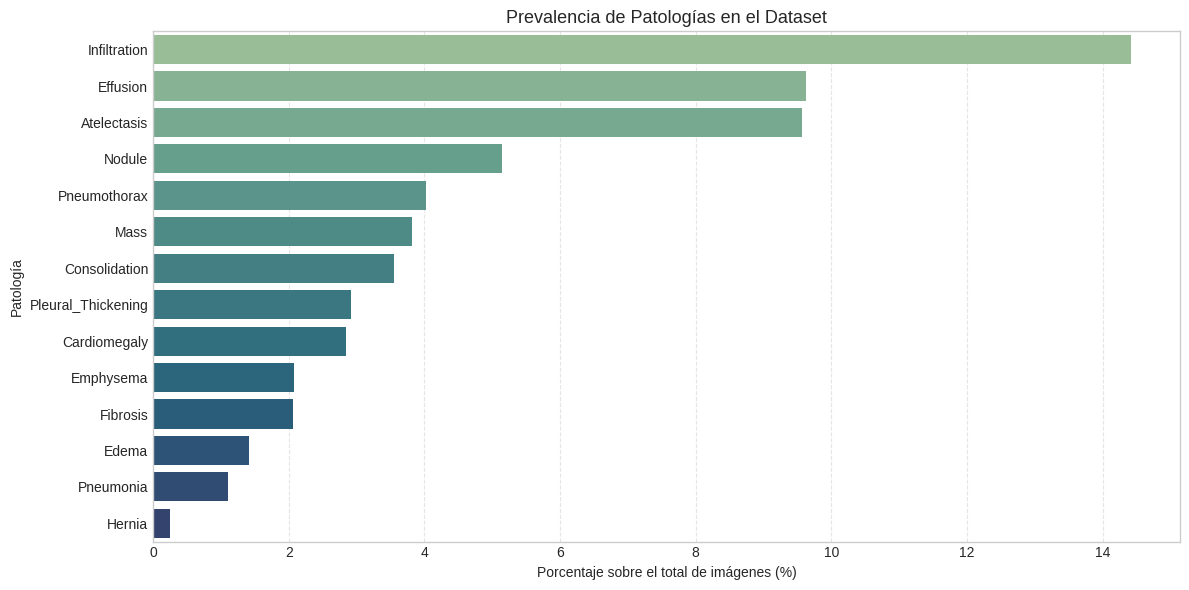

In [ ]:
# =====================================================
# CELDA 4 - EDA: FRECUENCIA DE PATOLOGÍAS
# =====================================================
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# -----------------------------------------------------
# 1. Calcular frecuencia de cada patología
# -----------------------------------------------------

disease_counts = (
    df[all_labels]
    .sum()
    .sort_values(ascending=False)
)

total_images = len(df)

# Las imágenes "No Finding" quedaron como cadena vacía
no_finding_count = (df["Finding Labels"] == "").sum()

print(f"Total de imágenes en el subconjunto: {total_images:,}")

print(
    f"Total sin hallazgos ('No Finding'): "
    f"{no_finding_count:,} "
    f"({no_finding_count / total_images * 100:.2f}%)"
)

# -----------------------------------------------------
# 2. Crear tabla resumen
# -----------------------------------------------------

df_disease_freq = pd.DataFrame({
    "Patología": disease_counts.index,
    "Casos": disease_counts.astype(int).values,
    "Porcentaje (%)": (
        disease_counts.values / total_images * 100
    ).round(2)
})

print("\nFrecuencia por patología:")
display(df_disease_freq)

# -----------------------------------------------------
# 3. Gráfico de prevalencia
# -----------------------------------------------------

plt.figure(figsize=(12, 6))

sns.barplot(
    data=df_disease_freq,
    x="Porcentaje (%)",
    y="Patología",
    hue="Patología",
    palette="crest",
    legend=False
)

plt.title(
    "Prevalencia de Patologías en el Dataset",
    fontsize=13
)

plt.xlabel(
    "Porcentaje sobre el total de imágenes (%)"
)

plt.ylabel("Patología")

plt.grid(
    axis="x",
    linestyle="--",
    alpha=0.5
)

plt.tight_layout()
plt.show()


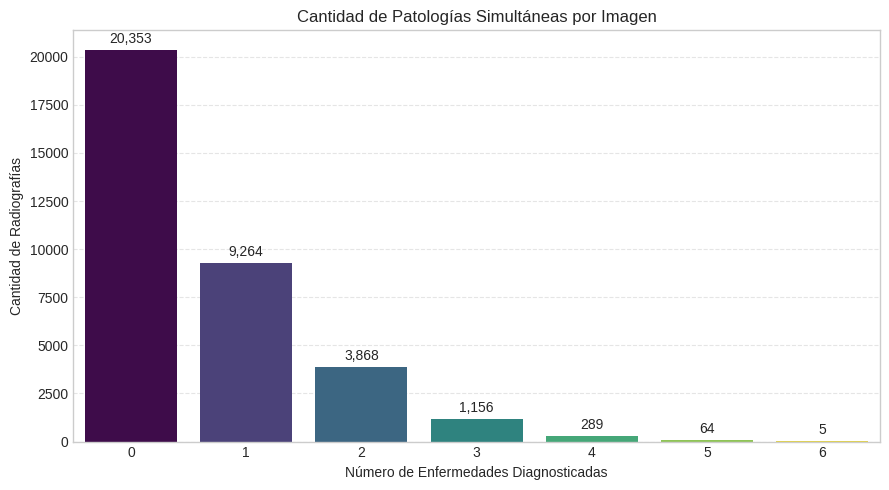

,Número de patologías,Cantidad de radiografías,Porcentaje (%)
0,0,20353,58.15
1,1,9264,26.47
2,2,3868,11.05
3,3,1156,3.30
4,4,289,0.83
5,5,64,0.18
6,6,5,0.01


In [ ]:
# =====================================================
# CELDA 5 - EDA: PATOLOGÍAS SIMULTÁNEAS POR IMAGEN
# =====================================================

import matplotlib.pyplot as plt
import seaborn as sns

# -----------------------------------------------------
# 1. Contar cuántas patologías tiene cada radiografía
# -----------------------------------------------------

df["disease_count"] = (
    df[all_labels]
    .sum(axis=1)
    .astype(int)
)

# -----------------------------------------------------
# 2. Visualizar distribución
# -----------------------------------------------------

plt.figure(figsize=(9, 5))

ax = sns.countplot(
    data=df,
    x="disease_count",
    hue="disease_count",
    palette="viridis",
    legend=False
)

# Mostrar número exacto encima de cada barra
for bar in ax.patches:

    height = bar.get_height()

    if height > 0:
        ax.annotate(
            f"{int(height):,}",
            (
                bar.get_x() + bar.get_width() / 2,
                height
            ),
            ha="center",
            va="bottom",
            fontsize=10,
            xytext=(0, 3),
            textcoords="offset points"
        )

plt.title(
    "Cantidad de Patologías Simultáneas por Imagen",
    fontsize=12
)

plt.xlabel(
    "Número de Enfermedades Diagnosticadas"
)

plt.ylabel(
    "Cantidad de Radiografías"
)

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.5
)

plt.tight_layout()
plt.show()

# -----------------------------------------------------
# 3. Tabla resumen
# -----------------------------------------------------

disease_count_summary = (
    df["disease_count"]
    .value_counts()
    .sort_index()
    .rename_axis("Número de patologías")
    .reset_index(name="Cantidad de radiografías")
)

disease_count_summary["Porcentaje (%)"] = (
    disease_count_summary["Cantidad de radiografías"]
    / len(df)
    * 100
).round(2)

display(disease_count_summary)



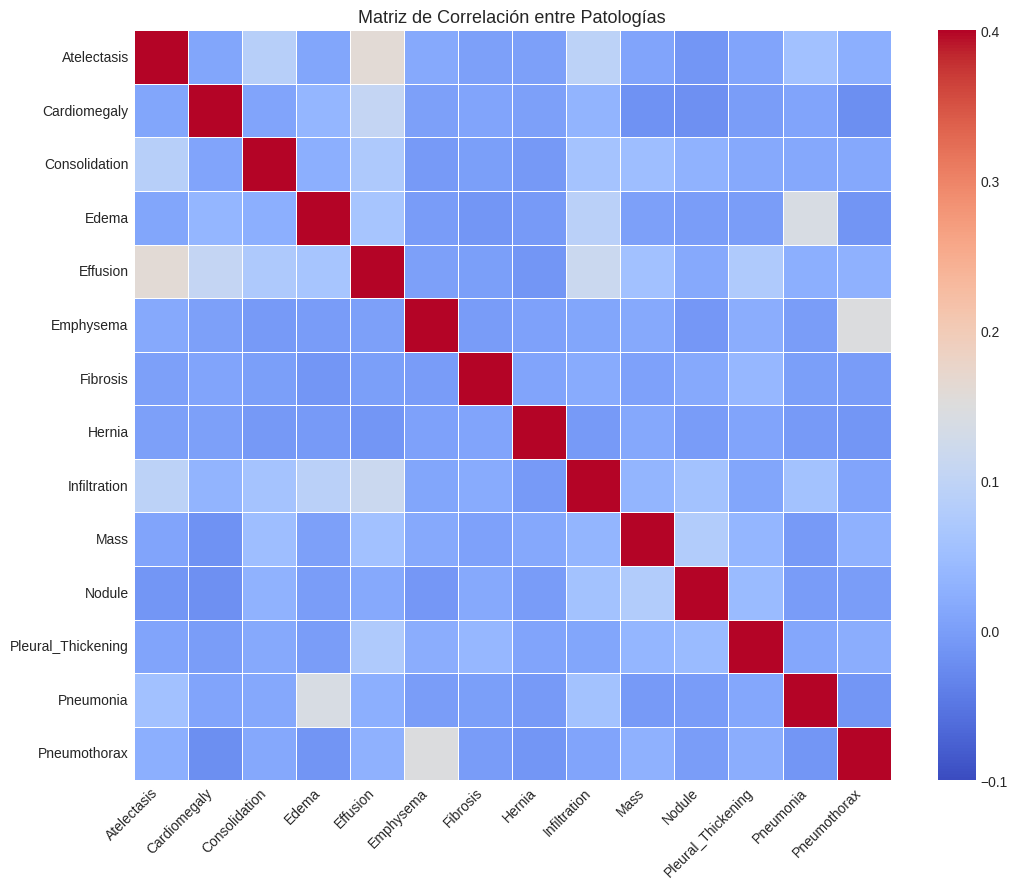

Top 10 correlaciones positivas entre patologías:


,Patología 1,Patología 2,Correlación
0,Atelectasis,Effusion,0.161401
1,Emphysema,Pneumothorax,0.146845
2,Edema,Pneumonia,0.139937
3,Effusion,Infiltration,0.114948
4,Cardiomegaly,Effusion,0.105707
5,Atelectasis,Infiltration,0.093923
6,Edema,Infiltration,0.089575
7,Atelectasis,Consolidation,0.085862
8,Mass,Nodule,0.078622
9,Effusion,Pleural_Thickening,0.074916


In [ ]:
# =====================================================
# CELDA 6 - EDA: CORRELACIÓN ENTRE PATOLOGÍAS
# =====================================================

import matplotlib.pyplot as plt
import seaborn as sns

# -----------------------------------------------------
# 1. Calcular matriz de correlación entre etiquetas
# -----------------------------------------------------

corr_matrix = df[all_labels].corr()

# -----------------------------------------------------
# 2. Visualizar Heatmap
# -----------------------------------------------------

plt.figure(figsize=(11, 9))

sns.heatmap(
    corr_matrix,
    cmap="coolwarm",
    vmin=-0.10,
    vmax=0.40,
    annot=False,
    linewidths=0.5
)

plt.title(
    "Matriz de Correlación entre Patologías",
    fontsize=13
)

plt.xticks(
    rotation=45,
    ha="right"
)

plt.yticks(
    rotation=0
)

plt.tight_layout()
plt.show()

# -----------------------------------------------------
# 3. Mostrar las correlaciones positivas más altas
#    excluyendo la diagonal
# -----------------------------------------------------

corr_pairs = (
    corr_matrix
    .where(
        np.triu(
            np.ones(corr_matrix.shape),
            k=1
        ).astype(bool)
    )
    .stack()
    .sort_values(ascending=False)
)

print("Top 10 correlaciones positivas entre patologías:")
display(
    corr_pairs
    .head(10)
    .reset_index()
    .rename(
        columns={
            "level_0": "Patología 1",
            "level_1": "Patología 2",
            0: "Correlación"
        }
    )
)



Registros antes del filtro de edad : 34,999
Registros después del filtro       : 34,998


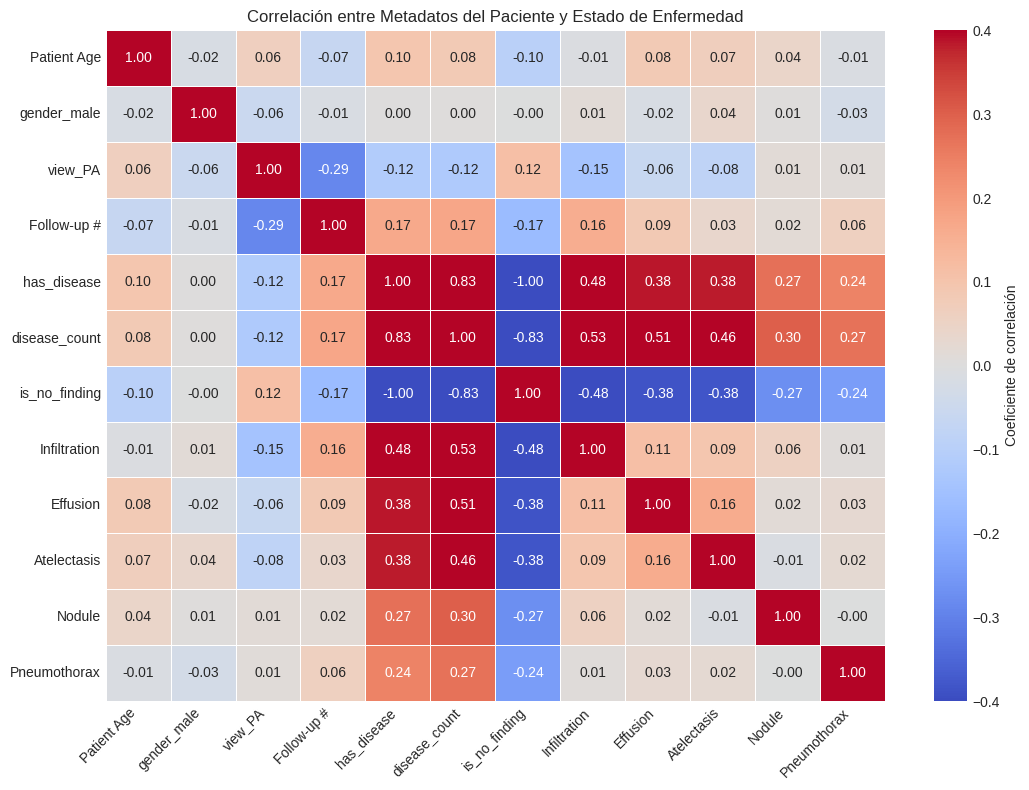

,Estado,total_imagenes,edad_promedio,pct_hombres,pct_vista_PA
0,Sano (No Finding),20353,46.12,53.65,65.55
1,Con Patología(s),14645,49.25,53.77,54.11


In [ ]:
# =====================================================
# CELDA 7 - EDA: METADATOS VS ESTADO DE ENFERMEDAD
# =====================================================

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# -----------------------------------------------------
# 1. Crear copia para EDA y filtrar edades anómalas
# -----------------------------------------------------

df_eda = df[df["Patient Age"] <= 100].copy()

print(f"Registros antes del filtro de edad : {len(df):,}")
print(f"Registros después del filtro       : {len(df_eda):,}")

# -----------------------------------------------------
# 2. Crear indicadores auxiliares SOLO PARA EDA
# -----------------------------------------------------

df_eda["has_disease"] = (
    df_eda[all_labels].sum(axis=1) > 0
).astype(int)

df_eda["is_no_finding"] = (
    df_eda["has_disease"] == 0
).astype(int)

df_eda["disease_count"] = (
    df_eda[all_labels]
    .sum(axis=1)
    .astype(int)
)

# -----------------------------------------------------
# 3. Codificar metadatos categóricos
# -----------------------------------------------------

df_eda["gender_male"] = (
    df_eda["Patient Gender"] == "M"
).astype(int)

df_eda["view_PA"] = (
    df_eda["View Position"] == "PA"
).astype(int)

# -----------------------------------------------------
# 4. Seleccionar variables de análisis
# -----------------------------------------------------

metadata_vars = [
    "Patient Age",
    "gender_male",
    "view_PA",
]

# Incluir Follow-up # solo si realmente existe
if "Follow-up #" in df_eda.columns:
    metadata_vars.append("Follow-up #")

metadata_vars += [
    "has_disease",
    "disease_count",
    "is_no_finding",
]

# Top 5 patologías más frecuentes
top_diseases = (
    df[all_labels]
    .sum()
    .sort_values(ascending=False)
    .head(5)
    .index
    .tolist()
)

analysis_cols = metadata_vars + top_diseases

# -----------------------------------------------------
# 5. Calcular matriz de correlación
# -----------------------------------------------------

metadata_corr = df_eda[analysis_cols].corr()

# -----------------------------------------------------
# 6. Visualizar Heatmap
# -----------------------------------------------------

plt.figure(figsize=(11, 8))

sns.heatmap(
    metadata_corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-0.4,
    vmax=0.4,
    linewidths=0.5,
    cbar_kws={
        "label": "Coeficiente de correlación"
    }
)

plt.title(
    "Correlación entre Metadatos del Paciente "
    "y Estado de Enfermedad",
    fontsize=12
)

plt.xticks(
    rotation=45,
    ha="right"
)

plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

# -----------------------------------------------------
# 7. Comparación directa: Sin hallazgos vs Patología
# -----------------------------------------------------

summary_metadata = (
    df_eda
    .groupby("has_disease")
    .agg(
        total_imagenes=("Image Index", "count"),
        edad_promedio=("Patient Age", "mean"),
        pct_hombres=(
            "gender_male",
            lambda x: x.mean() * 100
        ),
        pct_vista_PA=(
            "view_PA",
            lambda x: x.mean() * 100
        )
    )
    .reset_index()
)

summary_metadata["Estado"] = (
    summary_metadata["has_disease"]
    .map({
        0: "Sano (No Finding)",
        1: "Con Patología(s)"
    })
)

summary_metadata["edad_promedio"] = (
    summary_metadata["edad_promedio"].round(2)
)

summary_metadata["pct_hombres"] = (
    summary_metadata["pct_hombres"].round(2)
)

summary_metadata["pct_vista_PA"] = (
    summary_metadata["pct_vista_PA"].round(2)
)

summary_metadata = summary_metadata[
    [
        "Estado",
        "total_imagenes",
        "edad_promedio",
        "pct_hombres",
        "pct_vista_PA"
    ]
]

display(summary_metadata)


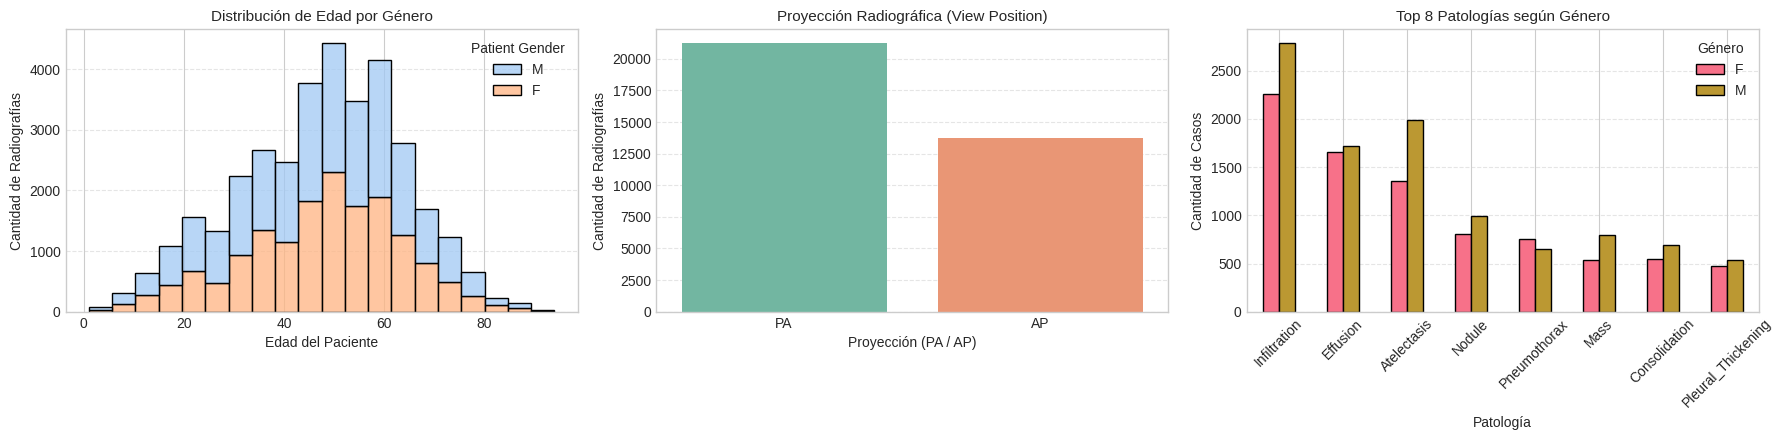

In [ ]:
# =====================================================
# CELDA 8 - EDA: DISTRIBUCIÓN DEMOGRÁFICA Y TÉCNICA
# =====================================================

import matplotlib.pyplot as plt
import seaborn as sns

# -----------------------------------------------------
# 1. Filtrar edades inconsistentes
# -----------------------------------------------------

df_clean = df[df["Patient Age"] <= 100].copy()

# -----------------------------------------------------
# 2. Crear figura con 3 gráficos
# -----------------------------------------------------

fig, axes = plt.subplots(
    1,
    3,
    figsize=(18, 4.5)
)

# -----------------------------------------------------
# A. Distribución de edad por género
# -----------------------------------------------------

sns.histplot(
    data=df_clean,
    x="Patient Age",
    hue="Patient Gender",
    multiple="stack",
    bins=20,
    ax=axes[0],
    palette="pastel"
)

axes[0].set_title(
    "Distribución de Edad por Género",
    fontsize=11
)

axes[0].set_xlabel(
    "Edad del Paciente"
)

axes[0].set_ylabel(
    "Cantidad de Radiografías"
)

axes[0].grid(
    axis="y",
    linestyle="--",
    alpha=0.5
)

# -----------------------------------------------------
# B. Distribución de la posición radiográfica
# -----------------------------------------------------

sns.countplot(
    data=df,
    x="View Position",
    hue="View Position",
    ax=axes[1],
    palette="Set2",
    legend=False
)

axes[1].set_title(
    "Proyección Radiográfica (View Position)",
    fontsize=11
)

axes[1].set_xlabel(
    "Proyección (PA / AP)"
)

axes[1].set_ylabel(
    "Cantidad de Radiografías"
)

axes[1].grid(
    axis="y",
    linestyle="--",
    alpha=0.5
)

# -----------------------------------------------------
# C. Top 8 patologías según género
# -----------------------------------------------------

gender_disease = (
    df
    .groupby("Patient Gender")[all_labels]
    .sum()
    .T
)

top8_gender = (
    gender_disease
    .assign(
        Total=lambda x: x.sum(axis=1)
    )
    .sort_values(
        by="Total",
        ascending=False
    )
    .head(8)
    .drop(columns="Total")
)

top8_gender.plot(
    kind="bar",
    ax=axes[2],
    edgecolor="black"
)

axes[2].set_title(
    "Top 8 Patologías según Género",
    fontsize=11
)

axes[2].set_xlabel(
    "Patología"
)

axes[2].set_ylabel(
    "Cantidad de Casos"
)

axes[2].tick_params(
    axis="x",
    rotation=45
)

axes[2].grid(
    axis="y",
    linestyle="--",
    alpha=0.5
)

axes[2].legend(
    title="Género"
)

plt.tight_layout()
plt.show()



### 4.4 Hallazgos del EDA

**Instrucciones:** Resuma los principales hallazgos de la exploración de datos:

---

**Hallazgos Principales:**
1. *El 58.15% de las imágenes (20,353) no presenta ninguna patología ("No Finding"), mientras que el 41.85% restante (14,646) presenta al menos una.*
2. *La patología más frecuente es Infiltración, presente en el 14.42% de las imágenes (5,048 casos), seguida de Derrame (9.63%) y Atelectasia (9.56%).*
3. *La patología menos frecuente es Hernia, presente en apenas el 0.25% de las imágenes (87 casos), seguida de Neumonía (1.10%) y Edema (1.42%).*
4. *El 26.47% de las imágenes presenta exactamente una patología, el 11.05% presenta dos, el 3.30% presenta tres, y existen casos con hasta seis patologías simultáneas en una misma radiografía, lo que confirma la naturaleza multietiqueta del problema.*
5. *Las correlaciones más altas entre patologías son moderadas: Atelectasia–Derrame (0.16), Enfisema–Neumotórax (0.15), Edema–Neumonía (0.14), Derrame–Infiltración (0.11) y Cardiomegalia–Derrame (0.11), lo que indica cierta co-ocurrencia clínica pero sin relaciones fuertes entre patologías.
Los pacientes con al menos una patología presentan una edad promedio ligeramente superior (49.25 años) frente a los pacientes sin hallazgos (46.12 años); la distribución por género es similar entre ambos grupos (~53.6%–53.8% hombres).*


**Problemas Identificados:**
1. *Desbalance severo de clases: la relación entre la patología más frecuente (Infiltración, 14.42%) y la menos frecuente (Hernia, 0.25%) es de aproximadamente 58 a 1.*
2. *Riesgo de que las métricas globales oculten un desempeño bajo en enfermedades poco frecuentes; este riesgo se confirma posteriormente en la sección de resultados, donde Nódulo y Neumonía —ambas de baja prevalencia o de difícil identificación visual— registran los ROC-AUC más bajos en ambos modelos.*
3. *Posible dificultad para discriminar patologías visualmente similares (por ejemplo, opacidades pulmonares compartidas entre Infiltración, Consolidation y Atelectasia), lo que se refleja en valores de ROC-AUC intermedios (0.70–0.75) para estas categorías.*
4. *La naturaleza multietiqueta del problema complica el uso de métricas de clasificación simples (como accuracy), dado que la mayoría de las etiquetas está fuertemente desbalanceada hacia la clase negativa.*


**Acciones a Tomar:**
1. *Data Augmentation sobre el conjunto de entrenamiento (rotación, desplazamientos horizontales/verticales y volteo horizontal) para incrementar la variabilidad de los ejemplos vistos por el modelo.*
2. *Transfer Learning utilizando backbones preentrenados en ImageNet (DenseNet121 y ResNet50) para aprovechar representaciones visuales genéricas ante un dataset de tamaño moderado.*
3. *Fine-Tuning en dos fases: extracción de características con el backbone congelado, seguido de un ajuste fino de las capas superiores con una tasa de aprendizaje reducida.*
4. *Evaluación mediante ROC-AUC por patología (y su promedio macro), métrica más robusta al desbalance de clases que la accuracy global.*
5. *Calibración de umbrales de decisión por patología, maximizando el F1-Score en el conjunto de validación, dado que el umbral por defecto de 0.5 resultó inadecuado ante clases minoritarias (evidenciado en el modelo DenseNet121, donde el recall promedio con umbral 0.5 fue de apenas 0.0086, frente a 0.3345 tras la calibración).*

---

---
## 5. Preprocesamiento de Datos

### 5.1 División de Datos (Train/Validation/Test)

#### ResNet

In [ ]:
from sklearn.model_selection import GroupShuffleSplit

# -----------------------------------------------------
# 1. Separar Train (70%) vs Temporal (30%)
#    agrupando por Patient ID
# -----------------------------------------------------

gss_train = GroupShuffleSplit(
    n_splits=1,
    train_size=0.70,
    random_state=RANDOM_SEED
)

train_idx, temp_idx = next(
    gss_train.split(
        df,
        groups=df["Patient ID"]
    )
)

train_df = (
    df.iloc[train_idx]
    .reset_index(drop=True)
)

temp_df = (
    df.iloc[temp_idx]
    .reset_index(drop=True)
)

# -----------------------------------------------------
# 2. Separar Temporal en Validation (15%) y Test (15%)
# -----------------------------------------------------

gss_val_test = GroupShuffleSplit(
    n_splits=1,
    train_size=0.50,
    random_state=RANDOM_SEED
)

val_idx, test_idx = next(
    gss_val_test.split(
        temp_df,
        groups=temp_df["Patient ID"]
    )
)

val_df = (
    temp_df.iloc[val_idx]
    .reset_index(drop=True)
)

test_df = (
    temp_df.iloc[test_idx]
    .reset_index(drop=True)
)

# -----------------------------------------------------
# 3. Mostrar tamaños
# -----------------------------------------------------

print(
    f"Train : {len(train_df):,} imágenes | "
    f"{train_df['Patient ID'].nunique():,} pacientes únicos"
)

print(
    f"Val   : {len(val_df):,} imágenes | "
    f"{val_df['Patient ID'].nunique():,} pacientes únicos"
)

print(
    f"Test  : {len(test_df):,} imágenes | "
    f"{test_df['Patient ID'].nunique():,} pacientes únicos"
)

# -----------------------------------------------------
# 4. Calcular porcentajes reales por imágenes
# -----------------------------------------------------

total = len(df)

print("\nDistribución real por imágenes:")

print(
    f"Train : {len(train_df) / total * 100:.2f}%"
)

print(
    f"Val   : {len(val_df) / total * 100:.2f}%"
)

print(
    f"Test  : {len(test_df) / total * 100:.2f}%"
)

# -----------------------------------------------------
# 5. Verificar DATA LEAKAGE entre pacientes
# -----------------------------------------------------

train_patients = set(train_df["Patient ID"])
val_patients = set(val_df["Patient ID"])
test_patients = set(test_df["Patient ID"])

train_val_overlap = train_patients & val_patients
train_test_overlap = train_patients & test_patients
val_test_overlap = val_patients & test_patients

print("\nVerificación de pacientes compartidos:")

print(
    f"Train ↔ Val  : {len(train_val_overlap)}"
)

print(
    f"Train ↔ Test : {len(train_test_overlap)}"
)

print(
    f"Val ↔ Test   : {len(val_test_overlap)}"
)

if (
    len(train_val_overlap) == 0
    and len(train_test_overlap) == 0
    and len(val_test_overlap) == 0
):
    print("\n✅ No existe fuga de pacientes entre conjuntos.")
else:
    print("\n⚠️ Se detectó solapamiento de pacientes.")



Train : 24,311 imágenes | 6,462 pacientes únicos
Val   : 5,245 imágenes | 1,385 pacientes únicos
Test  : 5,443 imágenes | 1,385 pacientes únicos

Distribución real por imágenes:
Train : 69.46%
Val   : 14.99%
Test  : 15.55%

Verificación de pacientes compartidos:
Train ↔ Val  : 0
Train ↔ Test : 0
Val ↔ Test   : 0

✅ No existe fuga de pacientes entre conjuntos.


#### DenseNet

In [ ]:
from sklearn.model_selection import GroupShuffleSplit

# 1. Separar Train (70%) vs Temp (30%) agrupando por 'Patient ID'
gss_train = GroupShuffleSplit(n_splits=1, train_size=0.70, random_state=42)
train_idx, temp_idx = next(gss_train.split(df, groups=df['Patient ID']))

train_df = df.iloc[train_idx].reset_index(drop=True)
temp_df = df.iloc[temp_idx].reset_index(drop=True)

# 2. Separar Temp en Validation (15%) y Test (15%) agrupando por 'Patient ID'
gss_val = GroupShuffleSplit(n_splits=1, train_size=0.50, random_state=42)
val_idx, test_idx = next(gss_val.split(temp_df, groups=temp_df['Patient ID']))

val_df = temp_df.iloc[val_idx].reset_index(drop=True)
test_df = temp_df.iloc[test_idx].reset_index(drop=True)

print(f"Total Train : {len(train_df):,} imágenes ({train_df['Patient ID'].nunique():,} pacientes únicos)")
print(f"Total Val   : {len(val_df):,} imágenes ({val_df['Patient ID'].nunique():,} pacientes únicos)")
print(f"Total Test  : {len(test_df):,} imágenes ({test_df['Patient ID'].nunique():,} pacientes únicos)")

# Verificación de fuga: Intersección de pacientes debe ser 0
overlap = set(train_df['Patient ID']).intersection(set(val_df['Patient ID'])).intersection(set(test_df['Patient ID']))
print(f"Pacientes compartidos entre conjuntos: {len(overlap)} (Correcto = 0)")

Total Train : 24,311 imágenes (6,462 pacientes únicos)
Total Val   : 5,245 imágenes (1,385 pacientes únicos)
Total Test  : 5,443 imágenes (1,385 pacientes únicos)
Pacientes compartidos entre conjuntos: 0 (Correcto = 0)


### 5.2 Preparación de Datos para Deep Learning

#### ResNet

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.resnet50 import preprocess_input

IMG_SIZE = (224, 224)
BATCH_SIZE = 32

# -----------------------------------------------------
# 2. Data Augmentation para entrenamiento
# -----------------------------------------------------

train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=10,
    width_shift_range=0.05,
    height_shift_range=0.05,
    horizontal_flip=True,
    fill_mode="nearest"
)

# -----------------------------------------------------
# 3. Validation y Test:
#    sin augmentation, solo preprocessing de ResNet50
# -----------------------------------------------------

val_test_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

# -----------------------------------------------------
# 4. Generador de entrenamiento
# -----------------------------------------------------

train_generator = train_datagen.flow_from_dataframe(
    dataframe=train_df,
    x_col="path",
    y_col=all_labels,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="raw",
    color_mode="rgb",
    shuffle=True,
    seed=RANDOM_SEED
)

# -----------------------------------------------------
# 5. Generador de validación
# -----------------------------------------------------

val_generator = val_test_datagen.flow_from_dataframe(
    dataframe=val_df,
    x_col="path",
    y_col=all_labels,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="raw",
    color_mode="rgb",
    shuffle=False
)

# -----------------------------------------------------
# 6. Generador de test
# -----------------------------------------------------

test_generator = val_test_datagen.flow_from_dataframe(
    dataframe=test_df,
    x_col="path",
    y_col=all_labels,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="raw",
    color_mode="rgb",
    shuffle=False
)

# -----------------------------------------------------
# 7. Verificaciones
# -----------------------------------------------------

print("\nResumen de generadores:")
print(f"Train      : {train_generator.samples:,} imágenes")
print(f"Validation : {val_generator.samples:,} imágenes")
print(f"Test       : {test_generator.samples:,} imágenes")

print(f"\nTamaño objetivo : {IMG_SIZE}")
print(f"Batch size      : {BATCH_SIZE}")
print(f"Número de clases: {len(all_labels)}")



Found 24311 validated image filenames.
Found 5245 validated image filenames.
Found 5443 validated image filenames.

Resumen de generadores:
Train      : 24,311 imágenes
Validation : 5,245 imágenes
Test       : 5,443 imágenes

Tamaño objetivo : (224, 224)
Batch size      : 32
Número de clases: 14


#### DenseNet

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

IMG_SIZE = (224, 224)
BATCH_SIZE = 32

# Pipeline de Data Augmentation para Train
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=10,
    width_shift_range=0.05,
    height_shift_range=0.05,
    horizontal_flip=True,
    fill_mode='nearest'
)

# Pipeline de Validación y Test (solo reescalado)
val_test_datagen = ImageDataGenerator(rescale=1./255)

# Generador de Entrenamiento
train_generator = train_datagen.flow_from_dataframe(
    dataframe=train_df,
    x_col='path',
    y_col=all_labels,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='raw',
    shuffle=True
)

# Generador de Validación
val_generator = val_test_datagen.flow_from_dataframe(
    dataframe=val_df,
    x_col='path',
    y_col=all_labels,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='raw',
    shuffle=False
)

# Generador de Test
test_generator = val_test_datagen.flow_from_dataframe(
    dataframe=test_df,
    x_col='path',
    y_col=all_labels,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='raw',
    shuffle=False
)

Found 24311 validated image filenames.
Found 5245 validated image filenames.
Found 5443 validated image filenames.


---
## 6. Diseño y Arquitectura del Modelo



### 6.1 Justificación de la Arquitectura

*Ambas arquitecturas son opciones consolidadas para tareas de clasificación de imágenes médicas mediante Transfer Learning, dada la disponibilidad de pesos preentrenados en ImageNet y su probada capacidad de extracción de características visuales genéricas (bordes, texturas, patrones de opacidad) transferibles al dominio radiológico.*

- DenseNet121 favorece la reutilización de características a través de sus conexiones densas, lo que puede mejorar el flujo de gradientes y la eficiencia paramétrica, resultando útil cuando se dispone de un volumen de datos moderado, como es el caso (34,999 imágenes).
- ResNet50 utiliza conexiones residuales que facilitan el entrenamiento de redes profundas al mitigar el problema de degradación del gradiente, y su bloque final (conv5_x) captura características de alto nivel que resultan especialmente relevantes para un ajuste fino focalizado.
- La estrategia de Fine-Tuning de ResNet50, al limitarse a un bloque arquitectónicamente definido (conv5_x) y mantener congeladas las capas de BatchNormalization, resulta más conservadora y menos arbitraria que el criterio de "últimas 35 capas" aplicado en DenseNet121, lo que puede favorecer una mayor estabilidad durante el ajuste fino.

Los documentos no detallan un proceso comparativo formal de selección de hiperarquitectura (por ejemplo, búsqueda de número de capas o neuronas mediante validación cruzada); ambos modelos reutilizan arquitecturas estándar de la literatura con una cabeza de clasificación idéntica, lo que permite una comparación controlada centrada en el backbone y la estrategia de Fine-Tuning.




---

### 6.2 Definición del Modelo

#### ResNet

In [ ]:
# =====================================================
# CELDA 12 - RESNET50 BASE: FEATURE EXTRACTION
# =====================================================

import os
import tensorflow as tf

from tensorflow.keras.applications import ResNet50
from tensorflow.keras.layers import (
    Dense,
    Dropout,
    GlobalAveragePooling2D
)
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.metrics import AUC

from tensorflow.keras.callbacks import (
    EarlyStopping,
    ModelCheckpoint,
    ReduceLROnPlateau,
    BackupAndRestore
)

# -----------------------------------------------------
# 1. Definir carpeta PERSISTENTE en Google Drive
# -----------------------------------------------------

RESULTS_DIR = (
    "/content/drive/MyDrive/"
    "Proyecto_Centrum PUCP/Modelos_Entrenados"
)

os.makedirs(RESULTS_DIR, exist_ok=True)

# Ruta permanente del mejor modelo base
BASE_MODEL_PATH = os.path.join(
    RESULTS_DIR,
    "best_resnet50_base.keras"
)

# Carpeta para recuperar entrenamiento interrumpido
BASE_BACKUP_DIR = os.path.join(
    RESULTS_DIR,
    "backup_base_training"
)

os.makedirs(BASE_BACKUP_DIR, exist_ok=True)

print("✅ Resultados persistentes en:")
print(RESULTS_DIR)

# -----------------------------------------------------
# 2. Cargar ResNet50 preentrenado con ImageNet
#    eliminando su clasificador original
# -----------------------------------------------------

resnet50_backbone = ResNet50(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

# -----------------------------------------------------
# 3. Congelar completamente el backbone
# -----------------------------------------------------

resnet50_backbone.trainable = False

# -----------------------------------------------------
# 4. Construir cabeza de clasificación multilabel
# -----------------------------------------------------

x = resnet50_backbone.output

x = GlobalAveragePooling2D(
    name="global_avg_pool"
)(x)

x = Dropout(
    0.30,
    name="dropout_regularization"
)(x)

outputs = Dense(
    len(all_labels),
    activation="sigmoid",
    name="multi_label_output"
)(x)

# -----------------------------------------------------
# 5. Construir modelo completo
# -----------------------------------------------------

resnet50_base_model = Model(
    inputs=resnet50_backbone.input,
    outputs=outputs,
    name="ResNet50_NIH_ChestXRay_Base"
)

# -----------------------------------------------------
# 6. Compilar
# -----------------------------------------------------

resnet50_base_model.compile(
    optimizer=Adam(
        learning_rate=1e-3
    ),
    loss="binary_crossentropy",
    metrics=[
        AUC(
            multi_label=True,
            num_labels=len(all_labels),
            name="auc_roc_macro"
        ),
        "binary_accuracy"
    ]
)

# -----------------------------------------------------
# 7. Callbacks
# -----------------------------------------------------

base_callbacks = [

    # Guardar permanentemente el mejor modelo en Drive
    ModelCheckpoint(
        filepath=BASE_MODEL_PATH,
        monitor="val_auc_roc_macro",
        mode="max",
        save_best_only=True,
        verbose=1
    ),

    # Detener si Validation AUC deja de mejorar
    EarlyStopping(
        monitor="val_auc_roc_macro",
        mode="max",
        patience=4,
        restore_best_weights=True,
        verbose=1
    ),

    # Reducir learning rate si Validation Loss se estanca
    ReduceLROnPlateau(
        monitor="val_loss",
        mode="min",
        factor=0.5,
        patience=2,
        min_lr=1e-6,
        verbose=1
    ),

    # MEJORA:
    # Guarda el estado del entrenamiento en Drive.
    # Si Colab interrumpe el runtime, model.fit() puede
    # continuar desde el último estado respaldado.
    BackupAndRestore(
        backup_dir=BASE_BACKUP_DIR
    )
]

# -----------------------------------------------------
# 8. Verificación de parámetros
# -----------------------------------------------------

total_params = resnet50_base_model.count_params()

trainable_params = int(
    sum(
        tf.keras.backend.count_params(w)
        for w in resnet50_base_model.trainable_weights
    )
)

non_trainable_params = int(
    sum(
        tf.keras.backend.count_params(w)
        for w in resnet50_base_model.non_trainable_weights
    )
)

print(f"\nModelo               : {resnet50_base_model.name}")
print(f"Patologías de salida : {len(all_labels)}")
print(f"Parámetros totales   : {total_params:,}")
print(f"Entrenables          : {trainable_params:,}")
print(f"No entrenables       : {non_trainable_params:,}")

print("\nModelo base se guardará en:")
print(BASE_MODEL_PATH)

print("\nBackup del entrenamiento:")
print(BASE_BACKUP_DIR)

✅ Resultados persistentes en:
/content/drive/MyDrive/Proyecto_Centrum PUCP/ResNet50_results
94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 6s 0us/step

Modelo               : ResNet50_NIH_ChestXRay_Base
Patologías de salida : 14
Parámetros totales   : 23,616,398
Entrenables          : 28,686
No entrenables       : 23,587,712

Modelo base se guardará en:
/content/drive/MyDrive/Proyecto_Centrum PUCP/ResNet50_results/best_resnet50_base.keras

Backup del entrenamiento:
/content/drive/MyDrive/Proyecto_Centrum PUCP/ResNet50_results/backup_base_training


#### DenseNet

In [ ]:
import os
import tensorflow as tf
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.metrics import AUC
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

# 1. Asegurar la existencia del directorio de resultados
os.makedirs('../results', exist_ok=True)

# 2. Cargar DenseNet121 pre-entrenado en ImageNet (sin el clasificador superior)
base_model = DenseNet121(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

# 3. Congelar capas base para el entrenamiento inicial (Feature Extraction)
base_model.trainable = False

# 4. Construir la cabeza de clasificación adaptada a multi-etiqueta
x = base_model.output
x = GlobalAveragePooling2D(name='global_avg_pool')(x)
x = Dropout(0.3, name='dropout_regularization')(x)
# Salida: 14 neuronas independientes con activación Sigmoid
predictions = Dense(len(all_labels), activation='sigmoid', name='multi_label_output')(x)

model = Model(inputs=base_model.input, outputs=predictions, name='DenseNet121_NIH_ChestXRay')

# 5. Compilar modelo
model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss='binary_crossentropy',
    metrics=[
        AUC(multi_label=True, name='auc_roc_macro'),
        'binary_accuracy'
    ]
)

# 6. Definir Callbacks para control de entrenamiento
callbacks_list = [
    # Guardar únicamente los pesos del mejor modelo según el AUC de validación
    ModelCheckpoint(
        filepath='../results/best_densenet121_model.keras',
        monitor='val_auc_roc_macro',
        mode='max',
        save_best_only=True,
        verbose=1
    ),
    # Detener el entrenamiento si el AUC no mejora durante 4 épocas consecutivas
    EarlyStopping(
        monitor='val_auc_roc_macro',
        mode='max',
        patience=4,
        restore_best_weights=True,
        verbose=1
    ),
    # Reducir la tasa de aprendizaje a la mitad si la pérdida de validación se estanca 2 épocas
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=2,
        min_lr=1e-6,
        verbose=1
    )
]


EPOCHS = 10

history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=EPOCHS,
    callbacks=callbacks_list,
    steps_per_epoch=len(train_generator),
    validation_steps=len(val_generator)
)

Epoch 1/10
760/760 [==============================] - ETA: 0s - loss: 0.1748 - auc_roc_macro: 0.5744 - binary_accuracy: 0.9531
Epoch 1: val_auc_roc_macro improved from -inf to 0.65949, saving model to ../results/best_densenet121_model.keras
760/760 [==============================] - 582s 764ms/step - loss: 0.1748 - auc_roc_macro: 0.5744 - binary_accuracy: 0.9531 - val_loss: 0.1672 - val_auc_roc_macro: 0.6595 - val_binary_accuracy: 0.9524 - lr: 0.0010
Epoch 2/10
760/760 [==============================] - ETA: 0s - loss: 0.1603 - auc_roc_macro: 0.6490 - binary_accuracy: 0.9556
Epoch 2: val_auc_roc_macro improved from 0.65949 to 0.69311, saving model to ../results/best_densenet121_model.keras
760/760 [==============================] - 578s 760ms/step - loss: 0.1603 - auc_roc_macro: 0.6490 - binary_accuracy: 0.9556 - val_loss: 0.1659 - val_auc_roc_macro: 0.6931 - val_binary_accuracy: 0.9524 - lr: 0.0010
Epoch 3/10
760/760 [==============================] - ETA: 0s - loss: 0.1575 - auc_roc_

### 6.3 Diagrama de la Arquitectura

---

*Arquitectura DenseNet121*

```
ENTRADA                         BACKBONE                         CABEZA                         SALIDA

[224×224×3]  ──>  [DenseNet121]  ──>  [GlobalAveragePooling2D]  ──>  [Dropout 0.3]  ──>  [Dense 14]  ──>  [14 patologías]
Radiografía         + ImageNet          + Transfer Learning          + Regularización      + Sigmoid
de tórax             + Fine-Tuning
                     + Últimas 35
                       capas
                     descongeladas

*Arquitectura ResNet50*
---
Input Layer              Backbone Layer                 Pooling Layer          Regularization       Output Layer
[224×224×3]       -->    [ResNet50]              -->    [GlobalAverage]  -->    [Dropout(0.3)]  -->  [Dense(14)]
Radiografía              + ImageNet                     Pooling2D                 ↓                   + Sigmoid
de tórax                  + Residual Blocks                                      Reduce
                          + Fine-Tuning                                           sobreajuste
                          + bloque conv5_x
                            descongelado
                          + BatchNorm congelada                     
```


---
## 7. Entrenamiento del Modelo

### 7.1 Configuración y Entrenamiento del Modelo

#### ResNet - Tecnica Transfer Learning

In [ ]:

import os
import numpy as np

# -----------------------------------------------------
# 1. Número máximo de épocas
# -----------------------------------------------------

EPOCHS_BASE = 10

# -----------------------------------------------------
# 2. Verificar si ya existe un modelo base guardado
# -----------------------------------------------------

if os.path.exists(BASE_MODEL_PATH):
    print("⚠️ Ya existe un modelo base guardado en Drive:")
    print(BASE_MODEL_PATH)
    print(
        "\nSi ejecutas model.fit(), se iniciará/continuará "
        "el entrenamiento usando el backup disponible."
    )
else:
    print("No existe todavía un modelo base guardado.")
    print("Se iniciará el entrenamiento.")

# -----------------------------------------------------
# 3. Entrenar modelo
# -----------------------------------------------------


history_base = resnet50_base_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=EPOCHS_BASE,
    callbacks=base_callbacks,
    steps_per_epoch=len(train_generator),
    validation_steps=len(val_generator)
)

# -----------------------------------------------------
# 4. Mostrar mejor desempeño alcanzado
# -----------------------------------------------------

best_epoch = (
    np.argmax(
        history_base.history["val_auc_roc_macro"]
    ) + 1
)

best_val_auc = max(
    history_base.history["val_auc_roc_macro"]
)

best_val_loss = min(
    history_base.history["val_loss"]
)

print("\n======================================")
print("RESUMEN DEL ENTRENAMIENTO BASE")
print("======================================")

print(
    f"Mejor época según Validation AUC : "
    f"{best_epoch}"
)

print(
    f"Mejor Validation ROC-AUC         : "
    f"{best_val_auc:.4f}"
)

print(
    f"Menor Validation Loss            : "
    f"{best_val_loss:.4f}"
)

print("\nModelo guardado permanentemente en:")
print(BASE_MODEL_PATH)

# -----------------------------------------------------
# 5. Verificar que el modelo realmente exista en Drive
# -----------------------------------------------------

if os.path.exists(BASE_MODEL_PATH):

    model_size_mb = (
        os.path.getsize(BASE_MODEL_PATH)
        / (1024 ** 2)
    )

    print("\n✅ Modelo confirmado en Google Drive.")
    print(
        f"Tamaño del archivo: "
        f"{model_size_mb:.2f} MB"
    )

else:
    print(
        "\n⚠️ El archivo del modelo no fue encontrado "
        "en Google Drive."
    )


No existe todavía un modelo base guardado.
Se iniciará el entrenamiento.
Epoch 1/10
760/760 ━━━━━━━━━━━━━━━━━━━━ 0s 991ms/step - auc_roc_macro: 0.5793 - binary_accuracy: 0.9468 - loss: 0.1935
Epoch 1: val_auc_roc_macro improved from None to 0.66802, saving model to /content/drive/MyDrive/Proyecto_Centrum PUCP/ResNet50_results/best_resnet50_base.keras

Epoch 1: finished saving model to /content/drive/MyDrive/Proyecto_Centrum PUCP/ResNet50_results/best_resnet50_base.keras
760/760 ━━━━━━━━━━━━━━━━━━━━ 893s 1s/step - auc_roc_macro: 0.6177 - binary_accuracy: 0.9529 - loss: 0.1736 - val_auc_roc_macro: 0.6680 - val_binary_accuracy: 0.9525 - val_loss: 0.1785 - learning_rate: 0.0010
Epoch 2/10
760/760 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - auc_roc_macro: 0.6716 - binary_accuracy: 0.9548 - loss: 0.1606
Epoch 2: val_auc_roc_macro improved from 0.66802 to 0.68242, saving model to /content/drive/MyDrive/Proyecto_Centrum PUCP/ResNet50_results/best_resnet50_base.keras

Epoch 2: finished saving model to /c

#### ResNet - Tecnica Fine-Tuning

In [ ]:
# =====================================================
#PREPARAR RESNET50 PARA FINE-TUNING
# =====================================================

import os
import tensorflow as tf

from tensorflow.keras.models import load_model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.metrics import AUC

# -----------------------------------------------------
# 1. Ruta permanente del mejor modelo Base
# -----------------------------------------------------

BASE_MODEL_PATH = (
    "/content/drive/MyDrive/Proyecto_Centrum PUCP/"
    "ResNet50_results/best_resnet50_base.keras"
)

FT_MODEL_PATH = (
    "/content/drive/MyDrive/Proyecto_Centrum PUCP/"
    "ResNet50_results/best_resnet50_finetuned.keras"
)

# Verificar existencia
if not os.path.exists(BASE_MODEL_PATH):
    raise FileNotFoundError(
        f"❌ No se encontró el modelo Base en:\n{BASE_MODEL_PATH}"
    )

print("✅ Modelo Base encontrado.")

# -----------------------------------------------------
# 2. Cargar el mejor ResNet50 Base
# -----------------------------------------------------

resnet50_ft_model = load_model(BASE_MODEL_PATH)

print(f"✅ Modelo cargado: {resnet50_ft_model.name}")

# -----------------------------------------------------
# 3. Congelar primero TODAS las capas
# -----------------------------------------------------

for layer in resnet50_ft_model.layers:
    layer.trainable = False

# -----------------------------------------------------
# 4. Descongelar únicamente el bloque conv5_x
# -----------------------------------------------------

for layer in resnet50_ft_model.layers:

    if layer.name.startswith("conv5_"):

        # MEJORA:
        # Las capas BatchNormalization permanecen
        # congeladas durante el Fine-Tuning.
        if not isinstance(
            layer,
            tf.keras.layers.BatchNormalization
        ):
            layer.trainable = True

# -----------------------------------------------------
# 5. Mantener entrenable la cabeza clasificadora
# -----------------------------------------------------

for layer_name in [
    "global_avg_pool",
    "dropout_regularization",
    "multi_label_output"
]:
    layer = resnet50_ft_model.get_layer(layer_name)
    layer.trainable = True

# -----------------------------------------------------
# 6. Contar capas entrenables y congeladas
# -----------------------------------------------------

trainable_layers = [
    layer.name
    for layer in resnet50_ft_model.layers
    if layer.trainable
]

frozen_layers = [
    layer.name
    for layer in resnet50_ft_model.layers
    if not layer.trainable
]

print("\nConfiguración para Fine-Tuning:")
print(f"Capas entrenables : {len(trainable_layers)}")
print(f"Capas congeladas  : {len(frozen_layers)}")

print("\nPrimeras capas entrenables detectadas:")

for name in trainable_layers[:15]:
    print(" -", name)

# -----------------------------------------------------
# 7. Recompilar con Learning Rate pequeño
# -----------------------------------------------------

resnet50_ft_model.compile(
    optimizer=Adam(
        learning_rate=1e-5
    ),
    loss="binary_crossentropy",
    metrics=[
        AUC(
            multi_label=True,
            num_labels=len(all_labels),
            name="auc_roc_macro"
        ),
        "binary_accuracy"
    ]
)

print("\n✅ Modelo recompilado para Fine-Tuning.")
print("Learning Rate: 1e-5")


✅ Modelo Base encontrado.
✅ Modelo cargado: ResNet50_NIH_ChestXRay_Base

Configuración para Fine-Tuning:
Capas entrenables : 25
Capas congeladas  : 153

Primeras capas entrenables detectadas:
 - conv5_block1_1_conv
 - conv5_block1_1_relu
 - conv5_block1_2_conv
 - conv5_block1_2_relu
 - conv5_block1_0_conv
 - conv5_block1_3_conv
 - conv5_block1_add
 - conv5_block1_out
 - conv5_block2_1_conv
 - conv5_block2_1_relu
 - conv5_block2_2_conv
 - conv5_block2_2_relu
 - conv5_block2_3_conv
 - conv5_block2_add
 - conv5_block2_out

✅ Modelo recompilado para Fine-Tuning.
Learning Rate: 1e-5


In [ ]:
# =====================================================
# ENTRENAMIENTO FINE-TUNING RESNET50
# =====================================================

import os
import numpy as np

from tensorflow.keras.callbacks import (
    EarlyStopping,
    ModelCheckpoint,
    ReduceLROnPlateau
)

# -----------------------------------------------------
# 1. Número máximo de épocas de Fine-Tuning
# -----------------------------------------------------

EPOCHS_FINE_TUNE = 5

# -----------------------------------------------------
# 2. Callbacks específicos para Fine-Tuning
# -----------------------------------------------------

fine_tune_callbacks = [

    ModelCheckpoint(
        filepath=FT_MODEL_PATH,
        monitor="val_auc_roc_macro",
        mode="max",
        save_best_only=True,
        verbose=1
    ),

    EarlyStopping(
        monitor="val_auc_roc_macro",
        mode="max",
        patience=3,
        restore_best_weights=True,
        verbose=1
    ),

    ReduceLROnPlateau(
        monitor="val_loss",
        mode="min",
        factor=0.5,
        patience=2,
        min_lr=1e-7,
        verbose=1
    )
]

# -----------------------------------------------------
# 3. Entrenamiento Fine-Tuning
# -----------------------------------------------------

print("======================================")
print("INICIO DEL FINE-TUNING")
print("======================================")

print(f"Épocas máximas      : {EPOCHS_FINE_TUNE}")
print("Learning Rate inicial: 1e-5")
print(f"Modelo de salida    : {FT_MODEL_PATH}")

history_fine_tune = resnet50_ft_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=EPOCHS_FINE_TUNE,
    callbacks=fine_tune_callbacks,
    steps_per_epoch=len(train_generator),
    validation_steps=len(val_generator)
)

# -----------------------------------------------------
# 4. Obtener mejor época
# -----------------------------------------------------

best_ft_epoch = (
    np.argmax(
        history_fine_tune.history["val_auc_roc_macro"]
    ) + 1
)

best_ft_val_auc = max(
    history_fine_tune.history["val_auc_roc_macro"]
)

best_ft_val_loss = min(
    history_fine_tune.history["val_loss"]
)

# -----------------------------------------------------
# 5. Mostrar resumen
# -----------------------------------------------------

print("\n======================================")
print("RESUMEN DEL FINE-TUNING")
print("======================================")

print(
    f"Mejor época según Validation AUC : "
    f"{best_ft_epoch}"
)

print(
    f"Mejor Validation ROC-AUC         : "
    f"{best_ft_val_auc:.4f}"
)

print(
    f"Menor Validation Loss            : "
    f"{best_ft_val_loss:.4f}"
)

print("\nModelo Fine-Tuned guardado en:")
print(FT_MODEL_PATH)

# -----------------------------------------------------
# 6. Verificar archivo
# -----------------------------------------------------

if os.path.exists(FT_MODEL_PATH):

    size_mb = (
        os.path.getsize(FT_MODEL_PATH)
        / (1024 ** 2)
    )

    print("\n✅ Modelo Fine-Tuned confirmado en Google Drive.")
    print(f"Tamaño del archivo: {size_mb:.2f} MB")

else:

    print(
        "\n⚠️ No se encontró el archivo Fine-Tuned "
        "en Google Drive."
    )



INICIO DEL FINE-TUNING
Épocas máximas      : 5
Learning Rate inicial: 1e-5
Modelo de salida    : /content/drive/MyDrive/Proyecto_Centrum PUCP/ResNet50_results/best_resnet50_finetuned.keras
Epoch 1/5
760/760 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - auc_roc_macro: 0.7665 - binary_accuracy: 0.9560 - loss: 0.1452
Epoch 1: val_auc_roc_macro improved from None to 0.72913, saving model to /content/drive/MyDrive/Proyecto_Centrum PUCP/ResNet50_results/best_resnet50_finetuned.keras

Epoch 1: finished saving model to /content/drive/MyDrive/Proyecto_Centrum PUCP/ResNet50_results/best_resnet50_finetuned.keras
760/760 ━━━━━━━━━━━━━━━━━━━━ 948s 1s/step - auc_roc_macro: 0.7695 - binary_accuracy: 0.9559 - loss: 0.1452 - val_auc_roc_macro: 0.7291 - val_binary_accuracy: 0.9521 - val_loss: 0.1595 - learning_rate: 1.0000e-05
Epoch 2/5
760/760 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - auc_roc_macro: 0.7901 - binary_accuracy: 0.9557 - loss: 0.1425
Epoch 2: val_auc_roc_macro improved from 0.72913 to 0.73672, saving model to

#### DenseNet - Tecnica Fine-Tuning

In [ ]:
from tensorflow.keras.models import load_model
from tensorflow.keras.optimizers.legacy import Adam
from tensorflow.keras.metrics import AUC
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

# 1. Cargar el mejor modelo previo
model = load_model('../results/best_densenet121_model.keras')

# 2. Descongelar únicamente las últimas 35 capas del modelo
# Primero congelamos todas
for layer in model.layers:
    layer.trainable = False

# Descongelamos las últimas 35 capas (bloque conv5 final y cabeza densa)
for layer in model.layers[-35:]:
    layer.trainable = True

# Verificar cuántas capas quedaron entrenables
trainable_count = sum([1 for l in model.layers if l.trainable])
non_trainable_count = sum([1 for l in model.layers if not l.trainable])
print(f"Capas congeladas: {non_trainable_count} | Capas entrenables para Fine-Tuning: {trainable_count}")

# 3. Recompilar con Learning Rate bajo (1e-5) para no destruir los pesos pre-entrenados
model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss='binary_crossentropy',
    metrics=[
        AUC(multi_label=True, name='auc_roc_macro'),
        'binary_accuracy'
    ]
)

# 4. Callbacks para la fase de Fine-Tuning
ft_callbacks = [
    ModelCheckpoint(
        filepath='../results/best_densenet121_finetuned.keras',
        monitor='val_auc_roc_macro',
        mode='max',
        save_best_only=True,
        verbose=1
    ),
    EarlyStopping(
        monitor='val_auc_roc_macro',
        mode='max',
        patience=3,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.2,
        patience=2,
        min_lr=1e-7,
        verbose=1
    )
]

# 5. Entrenar por 5 épocas adicionales de ajuste fino
history_ft = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=5,
    callbacks=ft_callbacks,
    steps_per_epoch=len(train_generator),
    validation_steps=len(val_generator)
)

Capas congeladas: 395 | Capas entrenables para Fine-Tuning: 35
Epoch 1/5
760/760 [==============================] - ETA: 0s - loss: 0.1730 - auc_roc_macro: 0.6753 - binary_accuracy: 0.9514
Epoch 1: val_auc_roc_macro improved from -inf to 0.68520, saving model to ../results/best_densenet121_finetuned.keras
760/760 [==============================] - 871s 1s/step - loss: 0.1730 - auc_roc_macro: 0.6753 - binary_accuracy: 0.9514 - val_loss: 0.1723 - val_auc_roc_macro: 0.6852 - val_binary_accuracy: 0.9515 - lr: 1.0000e-05
Epoch 2/5
760/760 [==============================] - ETA: 0s - loss: 0.1644 - auc_roc_macro: 0.6952 - binary_accuracy: 0.9534
Epoch 2: val_auc_roc_macro improved from 0.68520 to 0.69906, saving model to ../results/best_densenet121_finetuned.keras
760/760 [==============================] - 872s 1s/step - loss: 0.1644 - auc_roc_macro: 0.6952 - binary_accuracy: 0.9534 - val_loss: 0.1686 - val_auc_roc_macro: 0.6991 - val_binary_accuracy: 0.9516 - lr: 1.0000e-05
Epoch 3/5
760/76

---
## 8. Evaluación y Métricas

### 8.1 Evaluación en el Conjunto de Test

Cargando modelos DenseNet-121...
Construyendo y cargando pesos de ResNet-50...
Modelos listos para evaluación.
Found 5443 validated image filenames.
Found 5443 validated image filenames.

Inferencia DenseNet-121 Base...
171/171 [==============================] - 118s 685ms/step
Inferencia DenseNet-121 Fine-Tuned...
171/171 [==============================] - 116s 673ms/step
Inferencia ResNet-50 Base...
171/171 [==============================] - 123s 714ms/step
Inferencia ResNet-50 Fine-Tuned...
171/171 [==============================] - 119s 689ms/step


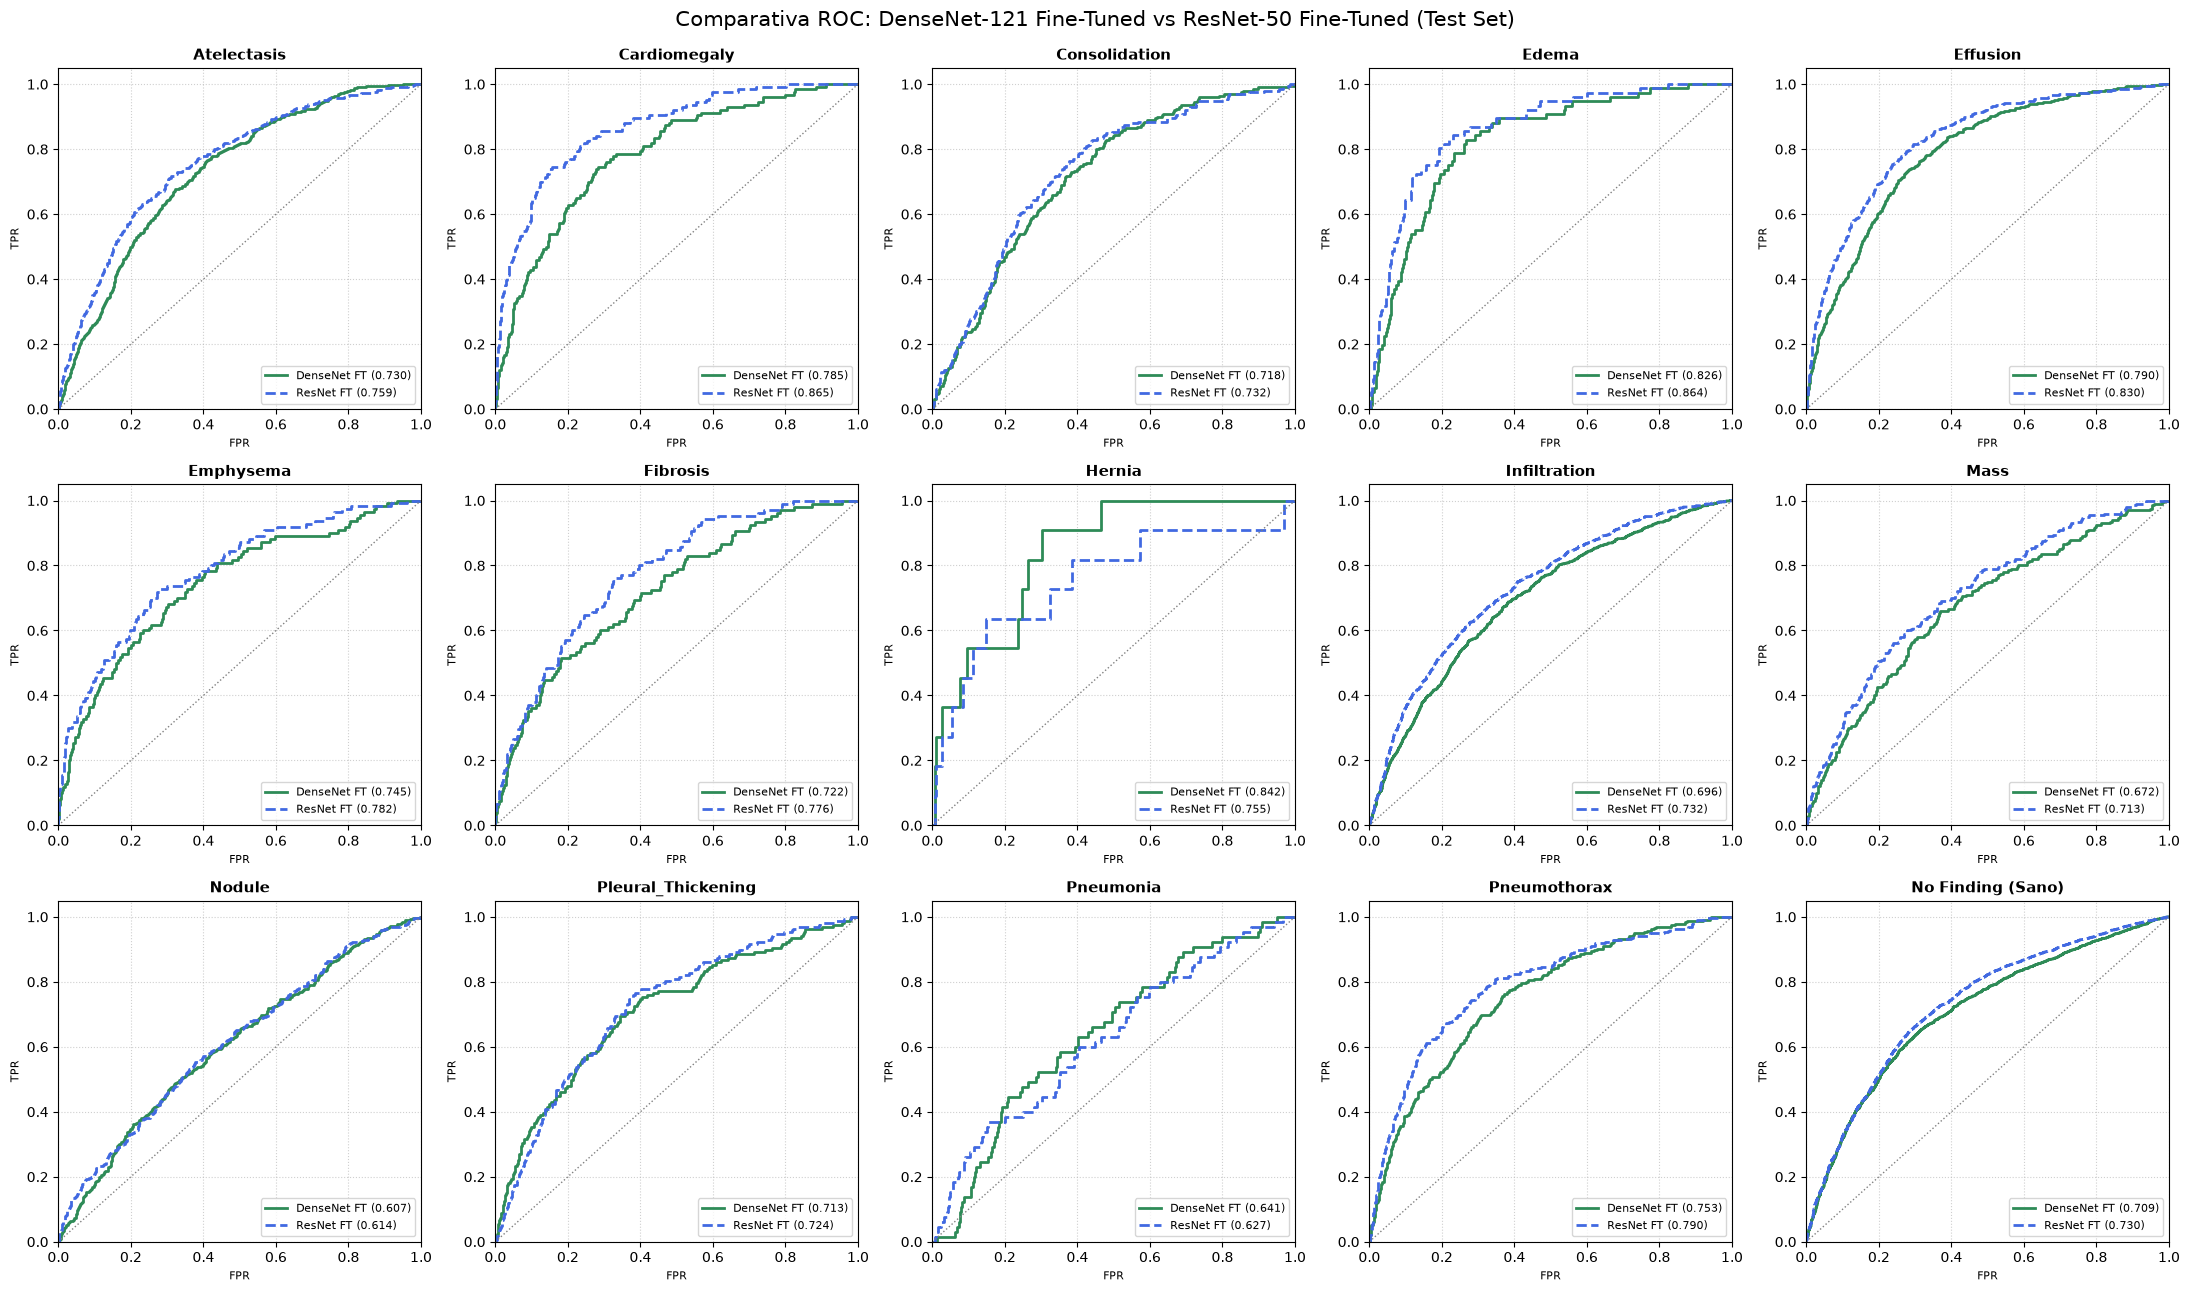


--- ROC-AUC MACRO RESNET-50 BASE     : 0.7317 ---
--- ROC-AUC MACRO RESNET-50 FT       : 0.7530 ---
--- ROC-AUC MACRO DENSENET-121 BASE  : 0.7238 ---
--- ROC-AUC MACRO DENSENET-121 FT    : 0.7299 ---


,Patología,ResNet-50 Base,ResNet-50 FT,DenseNet-121 Base,DenseNet-121 FT,Diferencia (DN FT - RN FT)
0,Hernia,0.7609,0.7550,0.8108,0.8422,0.0873
1,Edema,0.8425,0.8643,0.8129,0.8258,-0.0385
2,Effusion,0.8025,0.8296,0.7860,0.7899,-0.0397
3,Cardiomegaly,0.8054,0.8653,0.7577,0.7849,-0.0805
4,Pneumothorax,0.7588,0.7903,0.7488,0.7529,-0.0374
5,Emphysema,0.7563,0.7825,0.7424,0.7453,-0.0372
6,Atelectasis,0.7396,0.7591,0.7340,0.7298,-0.0293
7,Fibrosis,0.7607,0.7759,0.7206,0.7221,-0.0537
8,Consolidation,0.7125,0.7320,0.7167,0.7183,-0.0137
9,Pleural_Thickening,0.6993,0.7241,0.7282,0.7132,-0.0109


In [ ]:
# =====================================================
#EVALUACIÓN DE LOS 4 MODELOS EN TEST
# =====================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input as resnet_preprocess
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model, load_model

# 1. Cargar modelos DenseNet-121
print("Cargando modelos DenseNet-121...")
m_densenet_base = load_model('../results/best_densenet121_model.keras', compile=False)
m_densenet_ft   = load_model('../results/best_densenet121_finetuned.keras', compile=False)

# 2. Reconstruir arquitectura ResNet-50 y cargar pesos
def build_resnet50():
    base = ResNet50(weights=None, include_top=False, input_shape=(224, 224, 3))
    x = base.output
    x = GlobalAveragePooling2D(name='global_avg_pool')(x)
    x = Dropout(0.3, name='dropout_regularization')(x)
    preds = Dense(len(all_labels), activation='sigmoid', name='multi_label_output')(x)
    return Model(inputs=base.input, outputs=preds)

print("Construyendo y cargando pesos de ResNet-50...")
m_resnet_base = build_resnet50()
m_resnet_base.load_weights('../results/best_resnet50_base.keras')

m_resnet_ft = build_resnet50()
m_resnet_ft.load_weights('../results/best_resnet50_finetuned.keras')
print("Modelos listos para evaluación.")

# 3. Configurar generadores con el preprocesamiento específico de cada arquitectura
test_datagen_dn = ImageDataGenerator(rescale=1./255)
test_gen_dn = test_datagen_dn.flow_from_dataframe(
    dataframe=test_df,
    x_col='path',
    y_col=all_labels,
    target_size=(224, 224),
    batch_size=32,
    class_mode='raw',
    shuffle=False
)

test_datagen_rn = ImageDataGenerator(preprocessing_function=resnet_preprocess)
test_gen_rn = test_datagen_rn.flow_from_dataframe(
    dataframe=test_df,
    x_col='path',
    y_col=all_labels,
    target_size=(224, 224),
    batch_size=32,
    class_mode='raw',
    shuffle=False
)

# 4. Preparar datos de Test
y_true = np.array(test_df[all_labels])
y_true_nf = (y_true.sum(axis=1) == 0).astype(int)
y_true_all = np.column_stack([y_true, y_true_nf])
eval_labels = list(all_labels) + ['No Finding (Sano)']

def get_predictions(model, generator):
    generator.reset()
    probs = model.predict(generator, steps=len(generator), verbose=1)
    probs_nf = np.prod(1.0 - probs, axis=1)
    return np.column_stack([probs, probs_nf])

# 5. Generar inferencias con el preprocesamiento correspondiente
print("\nInferencia DenseNet-121 Base...")
preds_dn_base = get_predictions(m_densenet_base, test_gen_dn)

print("Inferencia DenseNet-121 Fine-Tuned...")
preds_dn_ft = get_predictions(m_densenet_ft, test_gen_dn)

print("Inferencia ResNet-50 Base...")
preds_rn_base = get_predictions(m_resnet_base, test_gen_rn)

print("Inferencia ResNet-50 Fine-Tuned...")
preds_rn_ft = get_predictions(m_resnet_ft, test_gen_rn)

# 6. Gráfica Comparativa Directa: DenseNet-121 FT vs ResNet-50 FT (15 Subplots)
fig, axes = plt.subplots(3, 5, figsize=(22, 13))
axes = axes.ravel()

comparison_table = []

for idx, label in enumerate(eval_labels):
    # DenseNet-121 Fine-Tuned
    fpr_dn_ft, tpr_dn_ft, _ = roc_curve(y_true_all[:, idx], preds_dn_ft[:, idx])
    auc_dn_ft = auc(fpr_dn_ft, tpr_dn_ft)

    # ResNet-50 Fine-Tuned
    fpr_rn_ft, tpr_rn_ft, _ = roc_curve(y_true_all[:, idx], preds_rn_ft[:, idx])
    auc_rn_ft = auc(fpr_rn_ft, tpr_rn_ft)

    # Modelos Base
    auc_dn_base = auc(*roc_curve(y_true_all[:, idx], preds_dn_base[:, idx])[:2])
    auc_rn_base = auc(*roc_curve(y_true_all[:, idx], preds_rn_base[:, idx])[:2])

    comparison_table.append({
        'Patología': label,
        'ResNet-50 Base': round(auc_rn_base, 4),
        'ResNet-50 FT': round(auc_rn_ft, 4),
        'DenseNet-121 Base': round(auc_dn_base, 4),
        'DenseNet-121 FT': round(auc_dn_ft, 4),
        'Diferencia (DN FT - RN FT)': round(auc_dn_ft - auc_rn_ft, 4)
    })

    ax = axes[idx]
    ax.plot(fpr_dn_ft, tpr_dn_ft, color='seagreen', lw=2, label=f'DenseNet FT ({auc_dn_ft:.3f})')
    ax.plot(fpr_rn_ft, tpr_rn_ft, color='royalblue', lw=2, linestyle='--', label=f'ResNet FT ({auc_rn_ft:.3f})')
    ax.plot([0, 1], [0, 1], color='grey', lw=1, linestyle=':')

    ax.set_title(label, fontsize=11, fontweight='bold')
    ax.set_xlim([0.0, 1.0])
    ax.set_ylim([0.0, 1.05])
    ax.set_xlabel('FPR', fontsize=8)
    ax.set_ylabel('TPR', fontsize=8)
    ax.legend(loc='lower right', fontsize=8)
    ax.grid(True, linestyle=':', alpha=0.6)

plt.suptitle('Comparativa ROC: DenseNet-121 Fine-Tuned vs ResNet-50 Fine-Tuned (Test Set)', fontsize=15, y=0.99)
plt.tight_layout()
plt.show()

# 7. Tabla Consolidada
df_all_models = pd.DataFrame(comparison_table).sort_values(by='DenseNet-121 FT', ascending=False).reset_index(drop=True)
print(f"\n--- ROC-AUC MACRO RESNET-50 BASE     : {df_all_models['ResNet-50 Base'].mean():.4f} ---")
print(f"--- ROC-AUC MACRO RESNET-50 FT       : {df_all_models['ResNet-50 FT'].mean():.4f} ---")
print(f"--- ROC-AUC MACRO DENSENET-121 BASE  : {df_all_models['DenseNet-121 Base'].mean():.4f} ---")
print(f"--- ROC-AUC MACRO DENSENET-121 FT    : {df_all_models['DenseNet-121 FT'].mean():.4f} ---")
display(df_all_models)

### 8.2 Comparativa de Curvas ROC: DenseNet-121 vs. ResNet-50 Fine-Tuned

Found 5443 validated image filenames.
Found 5443 validated image filenames.
Calculando predicciones DenseNet-121 FT...
171/171 [==============================] - 114s 664ms/step
Calculando predicciones ResNet-50 FT...
171/171 [==============================] - 117s 684ms/step


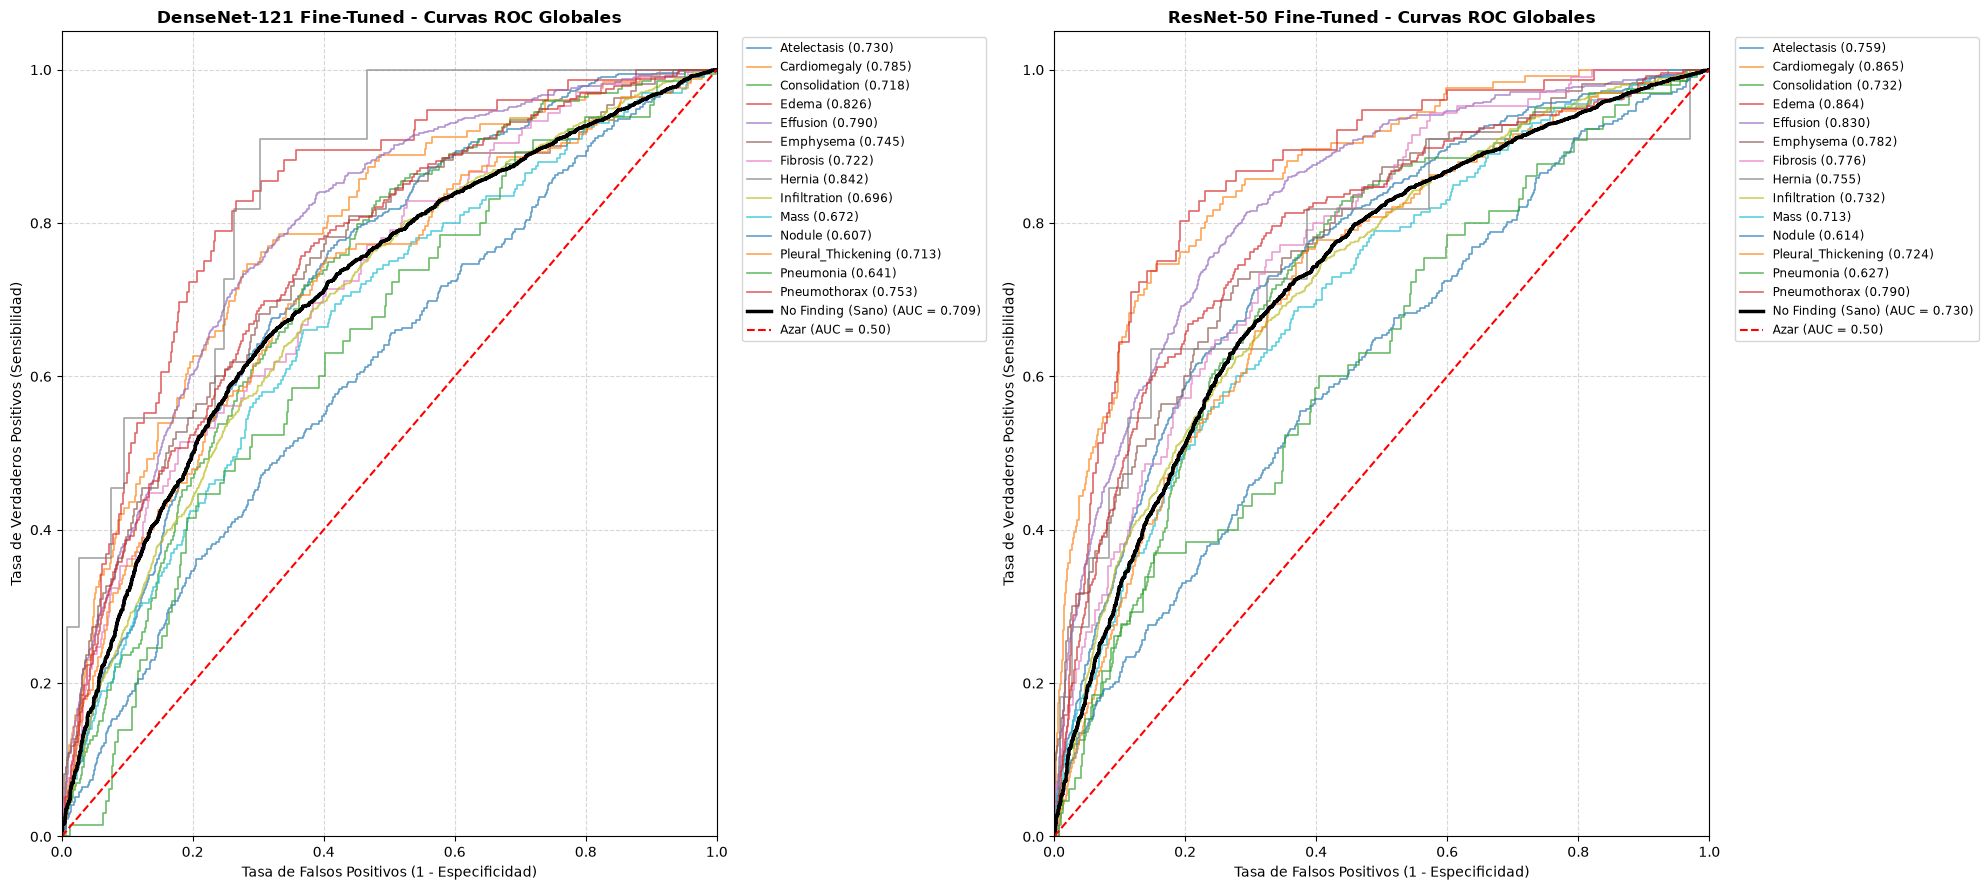

In [ ]:


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
from tensorflow.keras.applications.resnet50 import preprocess_input as resnet_preprocess
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import load_model

# 1. Preparar generadores con su respectivo preprocesamiento
# Generador estándar para DenseNet-121 (reescalado [0, 1])
test_datagen_dn = ImageDataGenerator(rescale=1./255)
test_gen_dn = test_datagen_dn.flow_from_dataframe(
    dataframe=test_df,
    x_col='path',
    y_col=all_labels,
    target_size=(224, 224),
    batch_size=32,
    class_mode='raw',
    shuffle=False
)

# Generador con preprocesamiento nativo para ResNet-50
test_datagen_rn = ImageDataGenerator(preprocessing_function=resnet_preprocess)
test_gen_rn = test_datagen_rn.flow_from_dataframe(
    dataframe=test_df,
    x_col='path',
    y_col=all_labels,
    target_size=(224, 224),
    batch_size=32,
    class_mode='raw',
    shuffle=False
)

# 2. Obtener etiquetas reales y calcular probabilidad para 'No Finding (Sano)'
y_true = np.array(test_df[all_labels])
y_true_nf = (y_true.sum(axis=1) == 0).astype(int)
y_true_all = np.column_stack([y_true, y_true_nf])
eval_labels = list(all_labels) + ['No Finding (Sano)']

# 3. Inferencia de DenseNet-121 Fine-Tuned
print("Calculando predicciones DenseNet-121 FT...")
test_gen_dn.reset()
preds_dn = ft_m.predict(test_gen_dn, steps=len(test_gen_dn), verbose=1)
preds_dn_nf = np.prod(1.0 - preds_dn, axis=1)
preds_dn_all = np.column_stack([preds_dn, preds_dn_nf])

# 4. Inferencia de ResNet-50 Fine-Tuned
print("Calculando predicciones ResNet-50 FT...")
test_gen_rn.reset()
preds_rn = m_resnet_ft.predict(test_gen_rn, steps=len(test_gen_rn), verbose=1)
preds_rn_nf = np.prod(1.0 - preds_rn, axis=1)
preds_rn_all = np.column_stack([preds_rn, preds_rn_nf])

# 5. Gráfica Comparativa: Dos paneles con todas las curvas por modelo
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 9))

# Panel Izquierdo: DenseNet-121 Fine-Tuned
for idx, label in enumerate(eval_labels):
    fpr, tpr, _ = roc_curve(y_true_all[:, idx], preds_dn_all[:, idx])
    roc_auc = auc(fpr, tpr)
    if label == 'No Finding (Sano)':
        ax1.plot(fpr, tpr, lw=2.5, color='black', label=f'{label} (AUC = {roc_auc:.3f})')
    else:
        ax1.plot(fpr, tpr, lw=1.2, alpha=0.7, label=f'{label} ({roc_auc:.3f})')

ax1.plot([0, 1], [0, 1], color='red', lw=1.5, linestyle='--', label='Azar (AUC = 0.50)')
ax1.set_xlim([0.0, 1.0])
ax1.set_ylim([0.0, 1.05])
ax1.set_xlabel('Tasa de Falsos Positivos (1 - Especificidad)', fontsize=10)
ax1.set_ylabel('Tasa de Verdaderos Positivos (Sensibilidad)', fontsize=10)
ax1.set_title('DenseNet-121 Fine-Tuned - Curvas ROC Globales', fontsize=12, fontweight='bold')
ax1.legend(bbox_to_anchor=(1.03, 1), loc='upper left', fontsize=8.5)
ax1.grid(True, linestyle='--', alpha=0.5)

# Panel Derecho: ResNet-50 Fine-Tuned
for idx, label in enumerate(eval_labels):
    fpr, tpr, _ = roc_curve(y_true_all[:, idx], preds_rn_all[:, idx])
    roc_auc = auc(fpr, tpr)
    if label == 'No Finding (Sano)':
        ax2.plot(fpr, tpr, lw=2.5, color='black', label=f'{label} (AUC = {roc_auc:.3f})')
    else:
        ax2.plot(fpr, tpr, lw=1.2, alpha=0.7, label=f'{label} ({roc_auc:.3f})')

ax2.plot([0, 1], [0, 1], color='red', lw=1.5, linestyle='--', label='Azar (AUC = 0.50)')
ax2.set_xlim([0.0, 1.0])
ax2.set_ylim([0.0, 1.05])
ax2.set_xlabel('Tasa de Falsos Positivos (1 - Especificidad)', fontsize=10)
ax2.set_ylabel('Tasa de Verdaderos Positivos (Sensibilidad)', fontsize=10)
ax2.set_title('ResNet-50 Fine-Tuned - Curvas ROC Globales', fontsize=12, fontweight='bold')
ax2.legend(bbox_to_anchor=(1.03, 1), loc='upper left', fontsize=8.5)
ax2.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

### 8.3 Análisis de Resultados

---

**Rendimiento del Modelo:**

*Los resultados de DenseNet121 y ResNet50 son distintos. Cuando se trata de ROC-AUC macro, ResNet50 muestra el mejor desempeño general y una mayor estabilidad entre las patologías analizadas, a diferencia de DenseNet121, que sobresale especialmente en clases con prevalencia muy baja. El recall efectivo mejoró significativamente en comparación con el umbral estándar de 0.5 cuando se calibraron los umbrales de DenseNet121, pero el F1-Score macro final sigue siendo bajo, lo que demuestra la complejidad del problema multietiqueta y la fuerte disparidad entre las patologías.*

**Comparación con Baselines:**

*En líneas generales, ResNet50 tiene un desempeño global superior al de DenseNet121, ya que lo supera en 12 de las 14 enfermedades y obtiene resultados más favorables en patologías importantes como el derrame y la cardiomegalia. No obstante, DenseNet121 obtiene un mejor rendimiento en Neumonía y Hernia, lo que demuestra una ventaja en ciertas enfermedades con baja prevalencia. Por lo tanto, ResNet50 puede ser considerado el modelo más consistente en términos generales; por su parte, DenseNet121 brinda beneficios particulares cuando se da preferencia a la identificación de ciertas clases minoritarias.*

**Fortalezas del Modelo:**

*DenseNet121*

1. *Buen desempeño relativo en patologías de muy baja prevalencia como Hernia y Neumonía, superando a ResNet50 en ambas.*
2. *Documenta un proceso completo de calibración de umbrales por patología basado en F1-Score sobre validación, lo que mejora sustancialmente el recall efectivo del modelo (de 0.0086 a 0.3345 en promedio) frente al umbral por defecto de 0.5.*

*ResNet50*

1. *Mejor ROC-AUC macro global y mejor desempeño en 12 de las 14 patologías evaluadas, mostrando mayor consistencia general.*
2. *Estrategia de Fine-Tuning más conservadora y arquitectónicamente justificada (bloque conv5_x con BatchNorm congelada), lo que se refleja en una curva de entrenamiento de Fine-Tuning con mejoras sostenidas de validación (de 0.729 a 0.744 de ROC-AUC) sin señales evidentes de sobreajuste severo en el corto plazo evaluado.*
3. *Mejor desempeño en patologías clínicamente relevantes por su severidad potencial, como Cardiomegalia (0.8653) y Derrame (0.8296).*


**Debilidades del Modelo:**

 *DenseNet121*

1. *Menor ROC-AUC macro general frente a ResNet50 tras el Fine-Tuning.*
2. *F1-Score macro con umbral calibrado sigue siendo bajo en términos absolutos (0.1638 en Test), reflejando la dificultad general del problema más que un defecto exclusivo del modelo.*
3. *Comportamiento inestable en Hernia bajo métricas de clasificación binaria (F1 = 0.0000 en Test pese a un ROC-AUC alto), lo que limita la confiabilidad de un umbral fijo para esta clase.*

*ResNet50*

1. *El documento no incluye, en el extracto disponible, el cálculo final de F1-Score con umbral calibrado sobre el conjunto de prueba, lo que impide una comparación completa de métricas de clasificación binaria entre ambos modelos.*
2. *Menor desempeño relativo en las patologías más escasas (Hernia y Neumonía) frente a DenseNet121.*
3. *El entrenamiento se ejecutó explícitamente sobre CPU (sin GPU disponible), lo que representa una limitación operativa que pudo restringir el número de épocas exploradas.*


**Posibles Mejoras:**
1. *Mejorar el tratamiento de la desproporción de clases: implementar métodos como class weights, focal loss o estrategias de sobremuestreo para mejorar la habilidad del modelo para identificar enfermedades poco frecuentes, sobre todo neumonía y hernia. Asimismo, se aconseja seguir con la calibración individual de los umbrales por patología para mejorar el balance entre la recuperación y la precisión.*
2. *Optimizar y expandir el proceso de evaluación y entrenamiento: emplear GPU para investigar más épocas y llevar a cabo una búsqueda sistemática de hiperparámetros. Del mismo modo, se sugiere calcular el F1-Score con umbrales calibrados para ResNet50 en el conjunto de prueba y comparar los modelos usando exactamente las mismas métricas y criterios de decisión. Esto posibilitaría una mayor evidencia para establecer cuál de las arquitecturas proporciona el balance más adecuado entre la discriminación y la clasificación efectiva.*

---

---
## 9. Interpretación de Resultados

In [ ]:
# =====================================================
# INTERPRETABILIDAD CON SHAP (OPCIONAL)
# =====================================================

# Instalar SHAP si no está disponible
# !pip install shap

try:
    import shap

    print("=" * 60)
    print("ANÁLISIS DE IMPORTANCIA DE FEATURES (SHAP)")
    print("=" * 60)

    # Crear explainer
    # Usar una muestra del dataset para acelerar el cálculo
    sample_size = min(100, len(X_test))
    X_sample = X_test.iloc[:sample_size]

    # Para modelos de sklearn (baselines)
    explainer = shap.TreeExplainer(baselines['Random Forest'])
    shap_values = explainer.shap_values(X_sample)

    # Visualización
    plt.figure(figsize=(12, 8))
    if task_type == 'classification' and len(shap_values) > 1:
        shap.summary_plot(shap_values[1], X_sample, plot_type="bar", show=False)
    else:
        shap.summary_plot(shap_values, X_sample, plot_type="bar", show=False)
    plt.title('Importancia de Features (SHAP)')
    plt.tight_layout()
    plt.show()

except ImportError:
    print("⚠️ SHAP no está instalado. Ejecute: !pip install shap")
except Exception as e:
    print(f"⚠️ Error en análisis SHAP: {e}")

### 9.2 Interpretación de Negocios

---

**Insights Principales:**
1. *Para profesionales de salud: un modelo con ROC-AUC macro de 0.75 (ResNet50) indica una capacidad de discriminación superior al azar (0.50) y moderadamente útil para varias patologías, pero insuficiente todavía para sustituir el juicio clínico; su mejor uso es como filtro de apoyo, no como herramienta de diagnóstico definitivo.*
2. *Para instituciones médicas: la posibilidad de generar una probabilidad por patología en cada radiografía permite imaginar flujos de trabajo donde los casos con mayor probabilidad de hallazgos relevantes (por ejemplo, sospecha de Cardiomegalia o Derrame, las patologías mejor detectadas) sean señalados para revisión prioritaria.*
3. *Para procesos de análisis de imágenes: la necesidad de recalibrar los umbrales de decisión por patología (y no usar un umbral genérico de 0.5) es un hallazgo operativo relevante: bajo el umbral por defecto, el recall promedio de DenseNet121 fue de apenas 0.0086, es decir, el modelo prácticamente no señalaba patologías positivas; tras calibrar el umbral en validación, el recall promedio subió a 0.3345. Esto demuestra que la forma de "leer" las salidas del modelo es tan importante como el modelo mismo.*
4. *Para la priorización de casos: dado que ambos modelos discriminan mejor ciertas patologías (Cardiomegalia, Edema, Derrame) que otras (Nódulo, Neumonía), una aplicación responsable debería comunicar de forma diferenciada el nivel de confianza del modelo según la patología evaluada, evitando dar la misma credibilidad a todas las predicciones.*
5. *Para el desarrollo futuro de herramientas de apoyo clínico: la existencia de patologías con muy pocos casos (Hernia, 87 imágenes) demuestra que ampliar el dataset en clases minoritarias, más que optimizar aún más el backbone, podría ser la palanca de mejora más significativa a corto plazo.*


**Factores y patrones identificados:**
1. *Patologías con mayor facilidad de clasificación: Cardiomegalia y Edema, en ambos modelos, posiblemente asociadas a patrones visuales más distintivos y globales en la imagen (forma y tamaño cardíaco, opacidad difusa).*
2. *Patologías con mayor dificultad: Nódulo y Neumonía, hallazgo consistente en ambos modelos, lo que sugiere una limitación del enfoque (y no solo del backbone específico) para detectar hallazgos focales pequeños o de presentación variable.*
3. *Impacto del desbalance de clases: se refleja de forma directa en la inestabilidad de las métricas de clasificación binaria para clases raras (por ejemplo, F1 = 0 en Hernia bajo umbral calibrado en DenseNet121, pese a un ROC-AUC relativamente alto de 0.84), y confirma la necesidad de evaluar estos modelos con métricas robustas al desbalance, no solo con accuracy o F1 simples.*
4. *Beneficio del Fine-Tuning: en ambos modelos, el ajuste fino mejoró el ROC-AUC de validación respecto a la fase base (DenseNet121: de un entorno de 0.65–0.71 a un máximo de 0.739 en validación; ResNet50: de 0.7207 a 0.7439 en validación), confirmando que liberar parte del backbone aporta valor incluso con un número reducido de épocas adicionales (5).*

---

---
## 10. Conclusiones y Recomendaciones de Negocio

### 10.1 Resumen de Resultados

*El proyecto abordó la clasificación automatizada y multietiqueta de 14 patologías torácicas a partir de radiografías del dataset NIH ChestX-ray14, comparando dos arquitecturas de Deep Learning basadas en Transfer Learning: DenseNet121 y ResNet50. Ambos modelos se entrenaron bajo el mismo esquema de dos fases (extracción de características seguida de Fine-Tuning) y se evaluaron sobre una partición de datos a nivel de paciente, libre de fuga de información.

Los resultados muestran que ResNet50 alcanzó el mejor desempeño global, con un ROC-AUC macro de 0.7546 en el conjunto de prueba tras el ajuste fino, superando a DenseNet121 (0.7314, calculado sobre las mismas 14 patologías) en 12 de las 14 categorías evaluadas. DenseNet121, sin embargo, mostró una ventaja puntual en dos patologías de muy baja prevalencia (Hernia y Neumonía), lo que matiza la conclusión y sugiere que ningún modelo domina de forma absoluta en todos los escenarios.

En conjunto, el proyecto demuestra que es factible construir un modelo de apoyo diagnóstico con capacidad de discriminación moderada, pero también evidencia limitaciones importantes —particularmente en patologías raras o visualmente ambiguas— que deben ser gestionadas explícitamente antes de considerar cualquier aplicación en un entorno clínico real. Con base en el desempeño global, la consistencia entre patologías y una estrategia de Fine-Tuning más conservadora, ResNet50 se recomienda como el modelo base para continuar el desarrollo del sistema.*

---

### 10.2 Conclusiones

1. El objetivo general del proyecto de desarrollar, entrenar y comparar dos modelos de Deep Learning para la clasificación multietiqueta de patologías torácicas; se logró, obteniendo resultados cuantitativos y comparables para ambas arquitecturas sobre el mismo conjunto de prueba.
2. El desempeño general de ambos modelos se ubica en un rango moderado (ROC-AUC macro entre 0.73 y 0.75), claramente superior al azar, pero insuficiente para una aplicación autónoma sin supervisión médica.
3. El principal desafío identificado es el fuerte desbalance de clases del dataset, que afecta de forma desproporcionada a patologías como Hernia, Neumonía y Nódulo, y que exige métricas de evaluación robustas (ROC-AUC) y calibración de umbrales específica por patología.
4. El modelo más conveniente, considerando el desempeño global y la consistencia entre patologías, es ResNet50; no obstante, persisten limitaciones relevantes, en particular la debilidad compartida por ambos modelos en Nódulo y Neumonía, y la falta en los documentos revisados de una evaluación de F1-Score calibrado en prueba para ResNet50, que impide una comparación totalmente simétrica entre ambos modelos.


---

### 10.3 Recomendaciones de Negocio


**Recomendaciones a Corto Plazo:**
1. Completar y estandarizar la calibración de umbrales de clasificación por patología para ambos modelos sobre el conjunto de validación, replicando en ResNet50 el proceso ya documentado para DenseNet121, de manera que ambos modelos sean evaluados con las mismas métricas de clasificación binaria (F1, precisión, recall) además del ROC-AUC.

2. Realizar un análisis detallado de errores por patología, con énfasis en Nódulo y Neumonía, para entender si los errores se concentran en subgrupos específicos (por ejemplo, por edad, género o posición de vista radiográfica).
3. Someter los resultados obtenidos a una evaluación clínica preliminar por parte de especialistas en radiología, antes de considerar cualquier paso adicional hacia una prueba piloto.

**Recomendaciones a Mediano Plazo:**
1. Incorporar una mayor cantidad de imágenes, en particular para las patologías con menor representación (Hernia, Neumonía, Edema), ya sea ampliando el subconjunto del propio NIH ChestX-ray14 o incorporando datasets externos compatibles.
2. Validar ambos modelos con conjuntos de datos externos al NIH ChestX-ray14, para evaluar su capacidad de generalización fuera del dataset de origen.
3. Optimizar hiperparámetros (tasa de aprendizaje, número de capas descongeladas, número de épocas de Fine-Tuning) de forma sistemática, dado que en ambos modelos el Fine-Tuning se limitó a solo 5 épocas.
4. Experimentar con estrategias adicionales de Fine-Tuning, incluyendo el descongelamiento progresivo de más bloques residuales o densos, y técnicas específicas para el manejo del desbalance de clases (por ejemplo, ponderación de clases o funciones de pérdida focales).


**Recomendaciones a Largo Plazo:**
1. Diseñar y ejecutar una validación en entornos clínicos reales, con supervisión de especialistas, antes de cualquier uso operativo del sistema.
2. Desarrollar un sistema de apoyo a decisiones clínicas que integre las probabilidades por patología junto con explicaciones visuales (por ejemplo, mapas de activación), facilitando la interpretación por parte del personal médico.
3. Explorar la integración del sistema con los flujos de trabajo hospitalarios existentes (sistemas de gestión de imágenes médicas), de forma que la priorización de casos sea parte natural del proceso y no una herramienta aislada.
4. Realizar estudios de robustez y generalización frente a variaciones de equipos de captura, poblaciones de pacientes y protocolos clínicos distintos a los del dataset de origen.


---

### 10.4 Limitaciones del Estudio

1. El subconjunto de imágenes utilizado (34,999) representa un 31% del total de registros del CSV original (112,120), por lo que los resultados podrían no ser representativos de la totalidad del dataset NIH ChestX-ray14.
2. Existe un desequilibrio marcado entre patologías, con clases como Hernia representadas por apenas 87 casos en todo el subconjunto, lo que limita la confiabilidad estadística de las métricas calculadas para dichas categorías.
3. El número de épocas de entrenamiento fue reducido (10 en la fase base y 5 en el Fine-Tuning para ambos modelos), lo que pudo limitar el desempeño máximo alcanzable; los documentos no reportan haber explorado configuraciones con mayor número de épocas.
4. Los documentos no proporcionan evidencia de validación externa (fuera del propio dataset NIH ChestX-ray14) ni de evaluación clínica real por parte de especialistas, por lo que la aplicabilidad práctica de los modelos no puede confirmarse a partir de la información disponible.
5. La comparación de tiempos de entrenamiento entre ambos modelos es parcial: el documento de ResNet50 confirma la ausencia de GPU, mientras que el de DenseNet121 no especifica el entorno de cómputo utilizado, lo que impide una comparación de eficiencia computacional completamente equivalente.
6. La clase "No Finding" utilizada en algunos análisis de ambos modelos es una construcción sintética (probabilidad conjunta de ausencia de las 14 patologías) y no una salida directamente aprendida por el modelo, por lo que debe interpretarse como una aproximación.


---

### 10.5 Trabajo Futuro

Ya realizado en este proyecto: preparación y exploración del dataset, entrenamiento base y Fine-Tuning de ambos modelos, evaluación mediante ROC-AUC por patología y global, y calibración de umbrales de decisión (completada para DenseNet121).

- Evaluación con datasets externos, para medir la capacidad de generalización de los modelos fuera del dataset NIH ChestX-ray14.
- Incorporación de técnicas específicas para el manejo del desbalance de clases (sobremuestreo de clases minoritarias, ponderación de clases en la función de pérdida, o funciones de pérdida focales).
- Optimización adicional de arquitecturas, incluyendo la evaluación de otros backbones preentrenados y la búsqueda sistemática de hiperparámetros.
- Uso de técnicas de explicabilidad (por ejemplo, mapas de activación de clase) que permitan visualizar en qué regiones de la radiografía se basa cada predicción, facilitando su revisión por especialistas.
- Validación por especialistas en radiología, como paso previo indispensable a cualquier uso del sistema en un entorno asistencial.
Desarrollo de una solución de apoyo clínico integrada, que combine las predicciones del modelo con la explicabilidad visual y con los flujos de trabajo hospitalarios existentes.


---

---
## 11. Referencias

Este informe se elaboró exclusivamente a partir de la información contenida en los siguientes documentos del proyecto, sin incorporar fuentes bibliográficas externas:
- Notebook "final_project.ipynb" (Google Colab) — Desarrollo, entrenamiento y evaluación del modelo DenseNet121 sobre el dataset NIH ChestX-ray14.
- Notebook "Final_project_ResNet50_v2.ipynb" (Google Colab) — Desarrollo, entrenamiento y evaluación del modelo ResNet50 sobre el dataset NIH ChestX-ray14.
- Dataset de referencia utilizado en ambos notebooks: NIH ChestX-ray14 (archivo de metadatos Data_Entry_2017.csv e imágenes asociadas).


---

---
## Anexos

### A. Guardado del Modelo

In [ ]:
# =====================================================
# GUARDAR EL MODELO ENTRENADO
# =====================================================

print("=" * 60)
print("GUARDADO DEL MODELO")
print("=" * 60)

# Guardar modelo PyTorch
MODEL_PATH = 'modelo_final.pth'
torch.save({
    'model_state_dict': model_pytorch.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'history': history,
    'hyperparameters': {
        'input_size': INPUT_SIZE,
        'hidden_sizes': HIDDEN_SIZES,
        'output_size': OUTPUT_SIZE,
        'dropout_rate': DROPOUT_RATE,
        'learning_rate': LEARNING_RATE
    }
}, MODEL_PATH)

print(f"\n✅ Modelo PyTorch guardado en: {MODEL_PATH}")

# Guardar modelo Keras (opcional)
# model_keras.save('modelo_final.keras')
# print(f"✅ Modelo Keras guardado en: modelo_final.keras")

# Guardar scaler
import joblib
joblib.dump(scaler, 'scaler.pkl')
print(f"✅ Scaler guardado en: scaler.pkl")

### B. Cargar Modelo Guardado (para Inferencia)

In [ ]:
# =====================================================
# CARGAR MODELO PARA INFERENCIA
# =====================================================

def load_model_and_predict(model_path, scaler_path, new_data):
    """
    Carga el modelo entrenado y hace predicciones sobre nuevos datos.

    Args:
        model_path: Ruta al archivo del modelo
        scaler_path: Ruta al archivo del scaler
        new_data: DataFrame con los nuevos datos

    Returns:
        Predicciones
    """
    # Cargar checkpoint
    checkpoint = torch.load(model_path, map_location=device)

    # Reconstruir modelo
    hp = checkpoint['hyperparameters']
    model = NeuralNetwork(
        hp['input_size'],
        hp['hidden_sizes'],
        hp['output_size'],
        hp['dropout_rate']
    )
    model.load_state_dict(checkpoint['model_state_dict'])
    model.to(device)
    model.eval()

    # Cargar scaler
    scaler = joblib.load(scaler_path)

    # Preprocesar datos
    new_data_scaled = scaler.transform(new_data)
    new_data_tensor = torch.FloatTensor(new_data_scaled).to(device)

    # Hacer predicción
    with torch.no_grad():
        outputs = model(new_data_tensor)
        if task_type == 'classification':
            _, predictions = torch.max(outputs, 1)
            predictions = predictions.cpu().numpy()
        else:
            predictions = outputs.cpu().numpy().flatten()

    return predictions

# Ejemplo de uso:
# predictions = load_model_and_predict('modelo_final.pth', 'scaler.pkl', new_df)
print("✅ Función de carga e inferencia definida")

---

## Checklist de Entrega

Antes de entregar, verifique que ha completado los siguientes elementos:

- [ ] Información del proyecto completada
- [ ] Resumen ejecutivo escrito
- [ ] Problema de negocio claramente definido
- [ ] Objetivos SMART establecidos
- [ ] EDA completo con visualizaciones
- [ ] Preprocesamiento de datos documentado
- [ ] Arquitectura del modelo justificada
- [ ] Modelo entrenado con curvas de aprendizaje
- [ ] Métricas de evaluación calculadas
- [ ] Comparación con modelos baseline
- [ ] Interpretación de resultados
- [ ] Conclusiones y recomendaciones de negocio
- [ ] Referencias listadas
- [ ] Código ejecutable sin errores
- [ ] Comentarios y documentación adecuados

---

**¡Buena suerte con su proyecto!** 🎓